# 🏥 Clasificación BI-RADS con BETO
### Auditoría de Coherencia Diagnóstica en Mamografía
**Autores:** Sebastián Inostroza · Robinson Moreno  
**Institución:** Universidad de Valparaíso  
**Año:** 2026

---

## ¿Qué hace este proyecto?
Detecta **disociación semántica** en informes de mamografía:
cuando un radiólogo describe hallazgos de alto riesgo
pero asigna una categoría BI-RADS baja.

## ¿Por qué BETO y no un modelo en inglés?
- El dataset está en español paraguayo
- Experiencia previa muestra degradación con modelos en inglés
- BETO fue preentrenado nativamente en español

In [1]:
# Verificar que las librerías se instalaron correctamente
import torch
import pandas as pd
import numpy as np
from transformers import BertTokenizerFast

print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ Pandas: {pd.__version__}")
print(f"✅ NumPy: {np.__version__}")
print(f"✅ Transformers instalado correctamente")
print(f"\n🖥️  GPU disponible: {torch.cuda.is_available()}")

/Users/sebas/Documents/Proyectos_Doc/proyecto-fund-pnl-mama/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ PyTorch: 2.12.0
✅ Pandas: 3.0.3
✅ NumPy: 2.4.6
✅ Transformers instalado correctamente

🖥️  GPU disponible: False


---
## PASO 1 — Carga del Dataset

### ¿Qué hacemos?
Cargamos el CSV con los 4.357 informes mamográficos y exploramos su estructura.

### ¿Por qué el separador es `;` y no `,`?
Los textos médicos contienen comas dentro de las oraciones.
Si usáramos `,` como separador, el parser rompería las columnas incorrectamente.

### ¿Qué columnas tiene el dataset?
- **Texto libre:** Observations, Conclusion, Full_Report
- **Variables clínicas:** Age, Children, LMP, Family_History
- **Objetivo:** BI-RADS (0 al 6) ← lo que queremos predecir

In [2]:
import os
import pandas as pd

# ── Detectar entorno automáticamente ─────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Configurar rutas según entorno ───────────────────────────────
if IN_COLAB:
    RESULTS_DIR = '/content/results'
else:
    RESULTS_DIR = '/Users/sebas/Documents/Proyectos_Doc/proyecto-fund-pnl-mama/results'

os.makedirs(f'{RESULTS_DIR}/figures', exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/metrics', exist_ok=True)

# ── Cargar datos ──────────────────────────────────────────────────
if IN_COLAB:
    from google.colab import files
    print('📂 Sube el archivo dataset_clean.csv')
    uploaded = files.upload()
    import io
    df = pd.read_csv(
        io.BytesIO(list(uploaded.values())[0]),
        encoding='utf-8'
    )
    DESDE_CURADO = True
else:
    BASE          = '/Users/sebas/Documents/Proyectos_Doc/proyecto-fund-pnl-mama'
    DATASET_CLEAN = f'{BASE}/data/processed/dataset_clean.csv'
    DATASET_RAW   = f'{BASE}/data/raw/BIRADS_radiology_reports.csv'
    if os.path.exists(DATASET_CLEAN):
        df = pd.read_csv(DATASET_CLEAN, encoding='utf-8')
        DESDE_CURADO = True
    else:
        df = pd.read_csv(DATASET_RAW, sep=';', encoding='utf-8')
        DESDE_CURADO = False

# ── Capa de compatibilidad ────────────────────────────────────────
if DESDE_CURADO:
    df['Observations'] = df['obs_clean']
    df['Conclusion']   = df['concl_clean']
    df['Full_Report']  = (
        df['obs_clean'] +
        '\nCONCLUSIÓN:\n' +
        df['concl_clean']
    )

print(f"✅ Dataset cargado: {df.shape[0]:,} registros")
print(f"🔗 Entorno:  {'Google Colab' if IN_COLAB else 'Mac local'}")
print(f"📁 Results:  {RESULTS_DIR}")
print(f"📋 Columnas: {df.columns.tolist()}")

✅ Dataset cargado
   Filas:    4,357
   Columnas: 15

📋 Nombres de columnas:
   - ID_R
   - Year
   - Month
   - Medical_Unit
   - Full_Report
   - LMP
   - Hormonal_Therapy
   - Family_History
   - Reason
   - Observations
   - Conclusion
   - Recommendations
   - BI-RADS
   - Age
   - Children


In [3]:
# Ver las primeras filas
print("📋 Primeras 2 filas (columnas clave):")
print(df[['ID_R', 'Year', 'Age', 'BI-RADS', 'Observations']].head(2).to_string())

print(f"\n📝 Ejemplo de texto real (primer informe):")
print(f"\nOBSERVACIONES:")
print(df['Observations'].iloc[0])
print(f"\nCONCLUSIÓN:")
print(df['Conclusion'].iloc[0])
print(f"\nBI-RADS ASIGNADO: {df['BI-RADS'].iloc[0]}")

📋 Primeras 2 filas (columnas clave):
       ID_R  Year   Age  BI-RADS                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    Observations
0  20190101  2019  48.0        0  MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y MEDIO LATERAL OBLÍCUAS\r\nNO SE OBSERVAN ALTERACIONES CUTÁNEAS NI DEL MAMELÓN.-\r\nLAS MAMAS SE PRESENTAN HETEROGÉNEAMENTE DENSAS, QUE PODRÍA OCULTAR ALGUNOS NÓDULOS PEQUEÑOS (TIPO C).\r\nEN EL CSE, PLANO POSTERIOR DE LA MAMA DERECHA, SE VISUA

---
## PASO 2 — Análisis de la Distribución BI-RADS

### ¿Qué hacemos?
Contamos cuántos registros hay de cada categoría BI-RADS.

### ¿Por qué es importante esto ANTES de entrenar?
Si no miramos la distribución, podríamos entrenar un modelo
que aprenda a predecir siempre BI-RADS 2 (la clase más común)
y tener 60% de accuracy... pero fallar en todos los casos de cáncer.

Esto se llama **desbalance de clases** y es el principal
desafío técnico de este proyecto.

In [4]:
# Contar registros por categoría BI-RADS
print("📊 Distribución de categorías BI-RADS:")
print("─" * 45)

birads_counts = df['BI-RADS'].value_counts().sort_index()

for categoria, cantidad in birads_counts.items():
    porcentaje = cantidad / len(df) * 100
    barra = '█' * int(porcentaje)
    print(f"  BI-RADS {categoria}: {cantidad:4d} ({porcentaje:5.1f}%)  {barra}")

print("─" * 45)
print(f"  TOTAL:     {len(df):4d} (100.0%)")

📊 Distribución de categorías BI-RADS:
─────────────────────────────────────────────
  BI-RADS 0:  966 ( 22.2%)  ██████████████████████
  BI-RADS 1:  596 ( 13.7%)  █████████████
  BI-RADS 2: 2635 ( 60.5%)  ████████████████████████████████████████████████████████████
  BI-RADS 3:   87 (  2.0%)  █
  BI-RADS 4:   52 (  1.2%)  █
  BI-RADS 5:   16 (  0.4%)  
  BI-RADS 6:    5 (  0.1%)  
─────────────────────────────────────────────
  TOTAL:     4357 (100.0%)


---
## PASO 3 — Análisis de Valores Faltantes

### ¿Qué hacemos?
Identificamos qué columnas tienen datos incompletos.

### ¿Por qué importa?
BETO no puede procesar valores vacíos.
Necesitamos saber qué tan incompleto está el dataset
antes de decidir cómo manejarlo.

In [5]:
# Analizar valores faltantes por columna
print("🔍 Valores faltantes por columna:")
print("─" * 45)

for col in df.columns:
    nulos = df[col].isna().sum()
    if nulos > 0:
        porcentaje = nulos / len(df) * 100
        print(f"  {col:20s}: {nulos:4d} ({porcentaje:.2f}%)")

print("─" * 45)
print("\n✅ Columnas sin valores faltantes: texto e ID completos")

🔍 Valores faltantes por columna:
─────────────────────────────────────────────
  LMP                 :  135 (3.10%)
  Recommendations     :   10 (0.23%)
  Age                 :   15 (0.34%)
  Children            :  125 (2.87%)
─────────────────────────────────────────────

✅ Columnas sin valores faltantes: texto e ID completos


---
## PASO 4 — Preprocesamiento del Texto

### ¿Qué hacemos?
Limpiamos el texto médico crudo para que BETO lo pueda procesar correctamente.

### ¿Por qué necesita limpieza?
El texto crudo tiene varios problemas:
- Está todo en MAYÚSCULAS
- Tiene saltos de línea `\r\n` dentro del texto
- Tiene guiones repetidos `.-` como separadores
- Tiene abreviaturas como `CSE`, `UCS` que BETO no conoce

### ¿Qué construimos como input para BETO?
Concatenamos dos secciones del informe:

    Observations [SEP] Conclusion

- **Observations** = lo que el radiólogo DESCRIBE (lo que ve)
- **Conclusion**   = lo que el radiólogo DECIDE (BI-RADS que asigna)
- **[SEP]**        = separador que le dice a BETO "estas son dos partes"

Así el modelo aprende si la descripción es coherente con la decisión.

In [6]:
import re

def limpiar_texto(texto):
    if pd.isna(texto):
        return ''
    texto = str(texto)
    # 1. Saltos de línea → espacio
    texto = re.sub(r'[\r\n\t]+', ' ', texto)
    # 2. Guiones repetidos → espacio
    texto = re.sub(r'-{2,}', ' ', texto)
    # 3. Minúsculas
    texto = texto.lower().strip()
    # 4. Solo caracteres útiles
    texto = re.sub(r'[^a-záéíóúüñ0-9\s\.,;:\-\(\)/]', ' ', texto)
    # 5. Espacios múltiples → uno solo
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Probar con el primer informe
ejemplo_original = df['Observations'].iloc[0]
ejemplo_limpio   = limpiar_texto(ejemplo_original)

print("ANTES:")
print(ejemplo_original[:200])
print("\nDESPUÉS:")
print(ejemplo_limpio[:200])

ANTES:
MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y MEDIO LATERAL OBLÍCUAS
NO SE OBSERVAN ALTERACIONES CUTÁNEAS NI DEL MAMELÓN.-
LAS MAMAS SE PRESENTAN HETEROGÉNEAMENTE DENSAS, QUE PODRÍA OCULTAR ALGUNOS N

DESPUÉS:
mamografía digital bilateral cráneo-caudal y medio lateral oblícuas no se observan alteraciones cutáneas ni del mamelón.- las mamas se presentan heterogéneamente densas, que podría ocultar algunos nód


In [7]:
# Diccionario de abreviaturas clínicas del dataset
ABREVIATURAS = {
    r'\bcse\b':  'cuadrante superoexterno',
    r'\bcsi\b':  'cuadrante superointerno',
    r'\bcie\b':  'cuadrante inferoexterno',
    r'\bcii\b':  'cuadrante inferointerno',
    r'\bucs\b':  'union de cuadrantes superiores',
    r'\buci\b':  'union de cuadrantes inferiores',
    r'\bgli\b':  'ganglio linfatico intramamario',
    r'\blpm\b':  'ultimo periodo menstrual',
    r'\bfur\b':  'fecha de ultima regla',
    r'\bacr\b':  'american college of radiology',
    r'\bbirads\b': 'bi-rads',
}

def limpiar_texto(texto):
    if pd.isna(texto):
        return ''
    texto = str(texto)
    # 1. Saltos de línea → espacio
    texto = re.sub(r'[\r\n\t]+', ' ', texto)
    # 2. Guiones repetidos → espacio
    texto = re.sub(r'-{2,}', ' ', texto)
    # 3. Minúsculas
    texto = texto.lower().strip()
    # 4. Expandir abreviaturas clínicas
    for patron, expansion in ABREVIATURAS.items():
        texto = re.sub(patron, expansion, texto)
    # 5. Solo caracteres útiles (conservando acentos)
    texto = re.sub(r'[^a-záéíóúüñ0-9\s\.,;:\-\(\)/]', ' ', texto)
    # 6. Espacios múltiples → uno solo
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Probar con ejemplo que tenga abreviaturas
ejemplo = "EN EL CSE DE LA MAMA DERECHA SE VISUALIZA NODULO. GLI EN REGION PECTOAXILAR."
print("ANTES:")
print(ejemplo)
print("\nDESPUÉS:")
print(limpiar_texto(ejemplo))

ANTES:
EN EL CSE DE LA MAMA DERECHA SE VISUALIZA NODULO. GLI EN REGION PECTOAXILAR.

DESPUÉS:
en el cuadrante superoexterno de la mama derecha se visualiza nodulo. ganglio linfatico intramamario en region pectoaxilar.


In [8]:
# Aplicar la función actualizada a todo el dataset
df['obs_clean']   = df['Observations'].apply(limpiar_texto)
df['concl_clean'] = df['Conclusion'].apply(limpiar_texto)

# Construir input final: Observations [SEP] Conclusion
df['texto_input'] = df['obs_clean'] + ' [SEP] ' + df['concl_clean']

# Verificar resultado
print("✅ Limpieza aplicada a los 4.357 registros")
print(f"\n📏 Estadísticas de longitud del texto_input:")
longitudes = df['texto_input'].str.split().str.len()
print(f"   Promedio: {longitudes.mean():.0f} palabras")
print(f"   Mínimo:   {longitudes.min():.0f} palabras")
print(f"   Máximo:   {longitudes.max():.0f} palabras")
print(f"   P95:      {longitudes.quantile(.95):.0f} palabras")
print(f"\n📝 Ejemplo del input final (primer registro):")
print("─" * 60)
print(df['texto_input'].iloc[0][:300])
print("─" * 60)

✅ Limpieza aplicada a los 4.357 registros

📏 Estadísticas de longitud del texto_input:
   Promedio: 99 palabras
   Mínimo:   50 palabras
   Máximo:   234 palabras
   P95:      149 palabras

📝 Ejemplo del input final (primer registro):
────────────────────────────────────────────────────────────
mamografía digital bilateral cráneo-caudal y medio lateral oblícuas no se observan alteraciones cutáneas ni del mamelón.- las mamas se presentan heterogéneamente densas, que podría ocultar algunos nódulos pequeños (tipo c). en el cuadrante superoexterno, plano posterior de la mama derecha, se visual
────────────────────────────────────────────────────────────


---
## PASO 5 — División del Dataset

### ¿Qué hacemos?
Dividimos los datos en tres conjuntos:
- **Train (70%)** → el modelo aprende con estos datos
- **Validación (15%)** → monitoreamos el entrenamiento por época
- **Test (15%)** → evaluación final, datos que el modelo NUNCA vio

### ¿Por qué usamos stratify?
Con solo 5 registros de BI-RADS 6, sin estratificación
podrían quedar 0 en el test set.
Stratify garantiza que la proporción de cada clase
se preserve en los tres conjuntos.

In [9]:
from sklearn.model_selection import train_test_split

X = df['texto_input'].values
y = df['BI-RADS'].values

# Split 1: (train+val) vs test
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Split 2: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=0.176,  # 15% del total
    random_state=42,
    stratify=y_tv
)

print("📊 División del dataset:")
print(f"   Train:      {len(X_train):4d} registros ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validación: {len(X_val):4d} registros ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test:       {len(X_test):4d} registros ({len(X_test)/len(X)*100:.1f}%)")

print("\n📋 BI-RADS en cada split:")
for nombre, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    from collections import Counter
    conteo = Counter(labels)
    dist = ', '.join([f'BI-RADS {k}:{v}' for k,v in sorted(conteo.items())])
    print(f"   {nombre:6s}: {dist}")

📊 División del dataset:
   Train:      3051 registros (70.0%)
   Validación:  652 registros (15.0%)
   Test:        654 registros (15.0%)

📋 BI-RADS en cada split:
   Train : BI-RADS 0:676, BI-RADS 1:418, BI-RADS 2:1845, BI-RADS 3:61, BI-RADS 4:36, BI-RADS 5:12, BI-RADS 6:3
   Val   : BI-RADS 0:145, BI-RADS 1:89, BI-RADS 2:394, BI-RADS 3:13, BI-RADS 4:8, BI-RADS 5:2, BI-RADS 6:1
   Test  : BI-RADS 0:145, BI-RADS 1:89, BI-RADS 2:396, BI-RADS 3:13, BI-RADS 4:8, BI-RADS 5:2, BI-RADS 6:1


In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calcular pesos solo sobre el conjunto de entrenamiento
# (nunca sobre val ni test — eso sería trampa)
clases = np.unique(y_train)
pesos  = compute_class_weight(
    class_weight='balanced',
    classes=clases,
    y=y_train
)

# Mostrar los pesos calculados
print("⚖️  Pesos de clase calculados:")
print("─" * 50)
nombres = {
    0: 'Incompleto',
    1: 'Negativo',
    2: 'Benigno',
    3: 'Prob. Benigno',
    4: 'Sospechoso',
    5: 'Alta sospecha',
    6: 'Maligno'
}
for cls, w in zip(clases, pesos):
    barra = '█' * min(int(w), 30)
    print(f"  BI-RADS {cls} ({nombres[cls]:14s}): {w:7.2f}  {barra}")
print("─" * 50)
print("\n💡 Mayor peso = mayor penalización por error en esa clase")

⚖️  Pesos de clase calculados:
──────────────────────────────────────────────────
  BI-RADS 0 (Incompleto    ):    0.64  
  BI-RADS 1 (Negativo      ):    1.04  █
  BI-RADS 2 (Benigno       ):    0.24  
  BI-RADS 3 (Prob. Benigno ):    7.15  ███████
  BI-RADS 4 (Sospechoso    ):   12.11  ████████████
  BI-RADS 5 (Alta sospecha ):   36.32  ██████████████████████████████
  BI-RADS 6 (Maligno       ):  145.29  ██████████████████████████████
──────────────────────────────────────────────────

💡 Mayor peso = mayor penalización por error en esa clase


---
## PASO 7 — Tokenización con BETO

### ¿Qué hacemos?
Convertimos el texto en números que BETO puede procesar.

### ¿Cómo funciona el tokenizador?
BETO no entiende palabras directamente, entiende números.
El tokenizador convierte cada palabra en un ID:

    "mamas densas tipo c"
    → [CLS] mama ##s den ##sas tipo c [SEP] [PAD]...
    → [ 101, 234,  456,  789, 1011, 1234, 567,  102,   0...]

- [CLS] → token especial que resume todo el texto
- [SEP] → separa Observations de Conclusion
- [PAD] → relleno hasta llegar a max_length=256
- Attention mask → 1=token real, 0=padding (BETO ignora el padding)

### ¿Por qué max_length=256?
El P95 del dataset es 149 palabras.
256 tokens cubre prácticamente todo el dataset con margen.

In [11]:
from transformers import BertTokenizerFast

# Cargar el tokenizador de BETO
# dccuchile = Universidad de Chile, creadores de BETO
# wwm = Whole Word Masking (enmascara palabras completas, no subpalabras)
# cased = distingue mayúsculas (importante para siglas médicas)
print("⏳ Descargando tokenizador BETO...")
print("   (primera vez tarda ~1 minuto, luego queda en caché)")

tokenizer = BertTokenizerFast.from_pretrained(
    'dccuchile/bert-base-spanish-wwm-cased'
)

print(f"✅ Tokenizador cargado")
print(f"   Vocabulario: {tokenizer.vocab_size:,} tokens")

# Probar con texto médico real
ejemplo = "las mamas se presentan heterogéneamente densas tipo c"
tokens  = tokenizer.tokenize(ejemplo)
print(f"\n📝 Ejemplo de tokenización:")
print(f"   Texto:    '{ejemplo}'")
print(f"   Tokens:   {tokens}")
print(f"   N° tokens: {len(tokens)}")

⏳ Descargando tokenizador BETO...
   (primera vez tarda ~1 minuto, luego queda en caché)


✅ Tokenizador cargado
   Vocabulario: 31,002 tokens

📝 Ejemplo de tokenización:
   Texto:    'las mamas se presentan heterogéneamente densas tipo c'
   Tokens:   ['las', 'mama', '##s', 'se', 'presentan', 'hetero', '##gén', '##eamente', 'den', '##sas', 'tipo', 'c']
   N° tokens: 12


In [12]:
# Ver exactamente qué le llega a BETO con un informe real
ejemplo_real = df['texto_input'].iloc[0]

encoding = tokenizer(
    ejemplo_real,
    max_length=256,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

print("📊 Estructura del input para BETO:")
print(f"   input_ids shape:      {encoding['input_ids'].shape}")
print(f"   attention_mask shape: {encoding['attention_mask'].shape}")

# Contar tokens reales vs padding
mask        = encoding['attention_mask'][0]
n_reales    = mask.sum().item()
n_padding   = 256 - n_reales

print(f"\n   Tokens reales:  {n_reales}")
print(f"   Tokens padding: {n_padding}")

# Ver los primeros tokens
ids_reales = encoding['input_ids'][0][:10].tolist()
tokens_reales = tokenizer.convert_ids_to_tokens(ids_reales)
print(f"\n   Primeros 10 tokens: {tokens_reales}")
print(f"   (101=[CLS], 102=[SEP], 0=[PAD])")

📊 Estructura del input para BETO:
   input_ids shape:      torch.Size([1, 256])
   attention_mask shape: torch.Size([1, 256])

   Tokens reales:  225
   Tokens padding: 31

   Primeros 10 tokens: ['[CLS]', 'mam', '##o', '##grafía', 'digital', 'bilateral', 'cráneo', '-', 'caudal', 'y']
   (101=[CLS], 102=[SEP], 0=[PAD])


---
## PASO 8 — Dataset y DataLoader PyTorch

### ¿Qué hacemos?
Creamos un objeto Dataset que PyTorch entiende
para alimentar el modelo durante el entrenamiento.

### ¿Por qué necesitamos esto?
PyTorch no puede leer directamente un array de textos.
Necesita un objeto que sepa:
- Cuántos ejemplos hay
- Cómo entregar cada ejemplo tokenizado

### ¿Qué es un DataLoader?
Es el que agrupa los ejemplos en batches.
En lugar de procesar 1 informe a la vez,
procesa 16 al mismo tiempo (batch_size=16).
Esto acelera enormemente el entrenamiento en GPU.

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader

class BIRADSDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        # Cuántos ejemplos tiene el dataset
        return len(self.texts)

    def __getitem__(self, idx):
        # Cómo entregar UN ejemplo tokenizado
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Crear los tres datasets
train_ds = BIRADSDataset(X_train, y_train, tokenizer)
val_ds   = BIRADSDataset(X_val,   y_val,   tokenizer)
test_ds  = BIRADSDataset(X_test,  y_test,  tokenizer)

# Crear los DataLoaders
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False)

print("✅ Datasets y DataLoaders creados")
print(f"\n   Train:      {len(train_ds):4d} ejemplos → {len(train_loader):3d} batches")
print(f"   Validación: {len(val_ds):4d} ejemplos → {len(val_loader):3d} batches")
print(f"   Test:       {len(test_ds):4d} ejemplos → {len(test_loader):3d} batches")

# Verificar un batch
batch = next(iter(train_loader))
print(f"\n📦 Estructura de un batch:")
print(f"   input_ids:      {batch['input_ids'].shape}")
print(f"   attention_mask: {batch['attention_mask'].shape}")
print(f"   labels:         {batch['label'].shape}")
print(f"   labels ejemplo: {batch['label'][:8].tolist()}")

✅ Datasets y DataLoaders creados

   Train:      3051 ejemplos → 191 batches
   Validación:  652 ejemplos →  41 batches
   Test:        654 ejemplos →  41 batches

📦 Estructura de un batch:
   input_ids:      torch.Size([16, 256])
   attention_mask: torch.Size([16, 256])
   labels:         torch.Size([16])
   labels ejemplo: [2, 0, 2, 1, 1, 2, 0, 1]


---
## PASO 9 — Arquitectura del Modelo BETO

### ¿Qué hacemos?
Definimos la red neuronal completa.

### ¿Cómo está construida?

    [Texto tokenizado]
          ↓
    BETO Encoder (110 millones de parámetros preentrenados)
          ↓
    Token [CLS] → vector de 768 números
          ↓
    Dropout (0.3) → apaga aleatoriamente 30% de neuronas
          ↓
    Capa densa 768 → 256
          ↓
    ReLU (activa solo valores positivos)
          ↓
    Dropout (0.3)
          ↓
    Capa densa 256 → 7 (una por cada BI-RADS)

### ¿Por qué Dropout?
Con solo 3 ejemplos de BI-RADS 6, el modelo puede memorizar
esos casos exactos en lugar de aprender el patrón general.
Dropout lo previene apagando neuronas aleatoriamente.

In [14]:
import torch.nn as nn
from transformers import BertModel

class BETOClasificadorBIRADS(nn.Module):
    def __init__(self, n_classes=7, dropout=0.3):
        super().__init__()

        # Cargar BETO preentrenado
        self.bert = BertModel.from_pretrained(
            'dccuchile/bert-base-spanish-wwm-cased'
        )

        # Cabeza clasificadora (la parte nueva que entrenaremos)
        self.clasificador = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(768, 256),  # 768 → 256
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)  # 256 → 7 clases
        )

    def forward(self, input_ids, attention_mask):
        # Pasar por BETO
        salida = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Tomar solo el token [CLS] (resumen del texto)
        cls_vector = salida.pooler_output  # (batch, 768)

        # Pasar por el clasificador
        logits = self.clasificador(cls_vector)  # (batch, 7)
        return logits

# Instanciar el modelo
DEVICE = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cpu')
print(f"🖥️  Dispositivo: {DEVICE}")

print("⏳ Cargando pesos preentrenados de BETO...")
model = BETOClasificadorBIRADS(n_classes=7, dropout=0.3).to(DEVICE)

# Contar parámetros
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Modelo listo")
print(f"   Parámetros totales:      {total:,}")
print(f"   Parámetros entrenables:  {trainable:,}")

🖥️  Dispositivo: mps
⏳ Cargando pesos preentrenados de BETO...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 48883.51it/s]
[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

✅ Modelo listo
   Parámetros totales:      110,049,543
   Parámetros entrenables:  110,049,543


---
## PASO 10 — Configuración del Entrenamiento

### ¿Qué hacemos?
Definimos tres componentes antes de entrenar:

### 1. Función de pérdida
CrossEntropyLoss con los pesos de clase calculados.
Mide qué tan equivocado está el modelo en cada predicción.

### 2. Optimizador AdamW
Ajusta los pesos del modelo para reducir el error.
Usamos AdamW (no Adam) porque es el estándar para BERT.
El learning rate 2e-5 es muy pequeño a propósito:
valores grandes destruirían los pesos preentrenados de BETO.

### 3. Scheduler con warmup
El learning rate no es fijo durante el entrenamiento:
- Primeras épocas: sube gradualmente de 0 → 2e-5
- Épocas siguientes: baja gradualmente de 2e-5 → 0

Esto protege los pesos preentrenados al inicio.

In [15]:
import torch.optim as optim
from transformers import get_linear_schedule_with_warmup

# ── 1. Función de pérdida con pesos de clase ──────────────
# Convertir pesos a tensor y mover al dispositivo
weight_tensor = torch.tensor(pesos, dtype=torch.float)

# Necesitamos pesos para las 7 clases (0-6)
# Si alguna clase no está en train, le damos peso 1.0
pesos_completos = torch.ones(7)
for cls, w in zip(clases, pesos):
    pesos_completos[cls] = w
pesos_completos = pesos_completos.to(DEVICE)

criterio = nn.CrossEntropyLoss(weight=pesos_completos)

# ── 2. Optimizador AdamW ───────────────────────────────────
LR = 2e-5
optimizador = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0.01
)

# ── 3. Scheduler con warmup ────────────────────────────────
EPOCHS       = 5
total_pasos  = len(train_loader) * EPOCHS
warmup_pasos = int(0.1 * total_pasos)  # 10% de warmup

scheduler = get_linear_schedule_with_warmup(
    optimizador,
    num_warmup_steps=warmup_pasos,
    num_training_steps=total_pasos
)

print("✅ Configuración lista")
print(f"\n   Learning rate:  {LR}")
print(f"   Épocas:         {EPOCHS}")
print(f"   Total pasos:    {total_pasos}")
print(f"   Warmup pasos:   {warmup_pasos}")
print(f"   Pesos de clase: {[round(p,2) for p in pesos_completos.tolist()]}")

✅ Configuración lista

   Learning rate:  2e-05
   Épocas:         5
   Total pasos:    955
   Warmup pasos:   95
   Pesos de clase: [0.64, 1.04, 0.24, 7.15, 12.11, 36.32, 145.29]


---
## PASO 11 — Entrenamiento del Modelo

### ¿Qué hacemos?
Entrenamos BETO época por época monitoreando el F1 Macro.

### ¿Por qué F1 Macro y no Accuracy?
Con clases desbalanceadas, Accuracy engaña:
- Predecir siempre BI-RADS 2 → 60% accuracy
- Pero F1 Macro sería ~0.09 → deja en evidencia el problema

F1 Macro trata todas las clases por igual sin importar
cuántos ejemplos tenga cada una.

### ¿Qué es Early Stopping?
Si el F1 en validación no mejora en 3 épocas seguidas,
paramos el entrenamiento. Esto evita que el modelo
memorice el train set y falle en datos nuevos.

### ¿Qué es Gradient Clipping?
Si el gradiente crece demasiado durante el entrenamiento
lo cortamos a máximo 1.0.
Previene que el modelo colapse con una actualización enorme.

In [16]:
from sklearn.metrics import f1_score
import time

def entrenar_epoca(model, loader, optimizador, scheduler, criterio, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    for batch in loader:
        ids    = batch['input_ids'].to(device)
        mask   = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizador.zero_grad()
        logits = model(ids, mask)
        loss   = criterio(logits, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizador.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(loader), correct / total, f1


def evaluar_epoca(model, loader, criterio, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            ids    = batch['input_ids'].to(device)
            mask   = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            logits = model(ids, mask)
            loss   = criterio(logits, labels)
            preds  = torch.argmax(logits, dim=1)

            total_loss += loss.item()
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(loader), correct / total, f1, all_preds, all_labels

print("✅ Funciones de entrenamiento definidas")
print("   Listo para iniciar el loop de entrenamiento")

✅ Funciones de entrenamiento definidas
   Listo para iniciar el loop de entrenamiento


In [18]:
# ── Variables de control ──────────────────────────────────
mejor_f1    = 0
mejor_epoca = 0
no_mejora   = 0
PATIENCE    = 3
historial   = {
    'tr_loss': [], 'vl_loss': [],
    'tr_f1':   [], 'vl_f1':   []
}

print("🏋️  Iniciando entrenamiento BETO BI-RADS")
print("─" * 65)
print(f"{'Época':6} | {'Train Loss':10} | {'Val Loss':10} | {'Train F1':10} | {'Val F1':10}")
print("─" * 65)

for epoca in range(1, EPOCHS + 1):
    t0 = time.time()

    # Entrenar
    tr_loss, tr_acc, tr_f1 = entrenar_epoca(
        model, train_loader, optimizador, scheduler, criterio, DEVICE
    )

    # Validar
    vl_loss, vl_acc, vl_f1, _, _ = evaluar_epoca(
        model, val_loader, criterio, DEVICE
    )

    elapsed = time.time() - t0

    # Guardar historial
    historial['tr_loss'].append(tr_loss)
    historial['vl_loss'].append(vl_loss)
    historial['tr_f1'].append(tr_f1)
    historial['vl_f1'].append(vl_f1)

    # Mostrar progreso
    mejora = '← mejor' if vl_f1 > mejor_f1 else ''
    print(f"{epoca:6d} | {tr_loss:10.4f} | {vl_loss:10.4f} | "
          f"{tr_f1:10.4f} | {vl_f1:10.4f}  {mejora}  ({elapsed:.0f}s)")

    # Guardar mejor modelo
    if vl_f1 > mejor_f1:
        mejor_f1    = vl_f1
        mejor_epoca = epoca
        no_mejora   = 0
        torch.save(model.state_dict(), os.path.join(RESULTS_DIR, 'mejor_beto.pt'))
    else:
        no_mejora += 1
        if no_mejora >= PATIENCE:
            print(f"\n⏹  Early stopping en época {epoca}")
            break

print("─" * 65)
print(f"🏆 Mejor modelo: época {mejor_epoca} — Val F1 = {mejor_f1:.4f}")

🏋️  Iniciando entrenamiento BETO BI-RADS
─────────────────────────────────────────────────────────────────
Época  | Train Loss | Val Loss   | Train F1   | Val F1    
─────────────────────────────────────────────────────────────────
     1 |     0.1824 |     0.3944 |     0.7322 |     0.6726  ← mejor  (144s)
     2 |     0.1814 |     0.3944 |     0.7630 |     0.6726    (144s)
     3 |     0.1837 |     0.3944 |     0.7589 |     0.6726    (144s)
     4 |     0.1703 |     0.3944 |     0.7288 |     0.6726    (144s)

⏹  Early stopping en época 4
─────────────────────────────────────────────────────────────────
🏆 Mejor modelo: época 1 — Val F1 = 0.6726


---
## PASO 11b — Reentrenamiento con Hiperparámetros Ajustados

### ¿Por qué ajustamos estos valores?
- **Learning rate 3e-5** → avanza un poco más rápido sin destruir BETO
- **Épocas 10** → más tiempo para aprender
- **Patience 4** → más tolerancia antes de parar

In [19]:
# Reiniciar el modelo desde cero
model = BETOClasificadorBIRADS(n_classes=7, dropout=0.3).to(DEVICE)

# Nuevos hiperparámetros
LR       = 3e-5
EPOCHS   = 10
PATIENCE = 4

optimizador = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0.01
)

total_pasos  = len(train_loader) * EPOCHS
warmup_pasos = int(0.1 * total_pasos)

scheduler = get_linear_schedule_with_warmup(
    optimizador,
    num_warmup_steps=warmup_pasos,
    num_training_steps=total_pasos
)

# Reiniciar variables de control
mejor_f1    = 0
mejor_epoca = 0
no_mejora   = 0
historial   = {
    'tr_loss': [], 'vl_loss': [],
    'tr_f1':   [], 'vl_f1':   []
}

print("🏋️  Reentrenamiento con hiperparámetros ajustados")
print(f"   LR: {LR} | Épocas: {EPOCHS} | Patience: {PATIENCE}")
print("─" * 65)
print(f"{'Época':6} | {'Train Loss':10} | {'Val Loss':10} | {'Train F1':10} | {'Val F1':10}")
print("─" * 65)

for epoca in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc, tr_f1 = entrenar_epoca(
        model, train_loader, optimizador, scheduler, criterio, DEVICE
    )
    vl_loss, vl_acc, vl_f1, _, _ = evaluar_epoca(
        model, val_loader, criterio, DEVICE
    )

    elapsed = time.time() - t0

    historial['tr_loss'].append(tr_loss)
    historial['vl_loss'].append(vl_loss)
    historial['tr_f1'].append(tr_f1)
    historial['vl_f1'].append(vl_f1)

    mejora = '← mejor' if vl_f1 > mejor_f1 else ''
    print(f"{epoca:6d} | {tr_loss:10.4f} | {vl_loss:10.4f} | "
          f"{tr_f1:10.4f} | {vl_f1:10.4f}  {mejora}  ({elapsed:.0f}s)")

    if vl_f1 > mejor_f1:
        mejor_f1    = vl_f1
        mejor_epoca = epoca
        no_mejora   = 0
        torch.save(model.state_dict(), os.path.join(RESULTS_DIR, 'mejor_beto.pt'))
    else:
        no_mejora += 1
        if no_mejora >= PATIENCE:
            print(f"\n⏹  Early stopping en época {epoca}")
            break

print("─" * 65)
print(f"🏆 Mejor modelo: época {mejor_epoca} — Val F1 = {mejor_f1:.4f}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 72639.81it/s]
[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

🏋️  Reentrenamiento con hiperparámetros ajustados
   LR: 3e-05 | Épocas: 10 | Patience: 4
─────────────────────────────────────────────────────────────────
Época  | Train Loss | Val Loss   | Train F1   | Val F1    
─────────────────────────────────────────────────────────────────
     1 |     1.3774 |     0.5993 |     0.2997 |     0.5151  ← mejor  (145s)
     2 |     0.4412 |     0.3413 |     0.5725 |     0.6727  ← mejor  (145s)
     3 |     0.2821 |     0.3586 |     0.7033 |     0.7590  ← mejor  (145s)
     4 |     0.1863 |     0.4395 |     0.7999 |     0.7597  ← mejor  (145s)
     5 |     0.1802 |     0.3244 |     0.8041 |     0.7671  ← mejor  (145s)
     6 |     0.1276 |     0.3183 |     0.8047 |     0.7671    (145s)
     7 |     0.0784 |     0.3584 |     0.8229 |     0.7656    (146s)
     8 |     0.0532 |     0.4051 |     0.8219 |     0.9200  ← mejor  (145s)
     9 |     0.0370 |     0.3740 |     0.9368 |     0.9200    (145s)
    10 |     0.0299 |     0.3800 |     0.9749 |     0.92

---
## PASO 12 — Evaluación Final en Test Set

### ¿Qué hacemos?
Cargamos el mejor modelo (época 8) y lo evaluamos
sobre el test set — datos que nunca vio durante el entrenamiento.

### ¿Por qué usamos el test set recién ahora?
Durante el entrenamiento solo miramos validación.
El test set es el "examen final" del modelo.
Si lo hubiéramos mirado antes, estaríamos haciendo trampa.

### ¿Qué métricas reportamos?
- F1 Macro → rendimiento global
- Recall BI-RADS 4-6 → sensibilidad oncológica
- Matriz de confusión → dónde se equivoca el modelo

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el mejor modelo guardado
model.load_state_dict(torch.load(os.path.join(RESULTS_DIR, 'mejor_beto.pt'), 
                                  map_location=DEVICE))

# Evaluar en test set
test_loss, test_acc, test_f1, test_preds, test_labels = evaluar_epoca(
    model, test_loader, criterio, DEVICE
)

# Métricas globales
print("=" * 55)
print("📊 RESULTADOS FINALES — TEST SET")
print("=" * 55)
print(f"  Accuracy:          {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  F1-Score (macro):  {test_f1:.4f}")
print("=" * 55)

# Reporte por clase
print("\n📋 Reporte por clase:")
print(classification_report(
    test_labels, test_preds,
    target_names=[f'BI-RADS {i}' for i in range(7)],
    zero_division=0
))

📊 RESULTADOS FINALES — TEST SET
  Accuracy:          0.9801 (98.01%)
  F1-Score (macro):  0.8786

📋 Reporte por clase:
              precision    recall  f1-score   support

   BI-RADS 0       0.99      0.99      0.99       145
   BI-RADS 1       1.00      0.99      0.99        89
   BI-RADS 2       0.99      0.99      0.99       396
   BI-RADS 3       0.67      0.77      0.71        13
   BI-RADS 4       0.86      0.75      0.80         8
   BI-RADS 5       1.00      0.50      0.67         2
   BI-RADS 6       1.00      1.00      1.00         1

    accuracy                           0.98       654
   macro avg       0.93      0.85      0.88       654
weighted avg       0.98      0.98      0.98       654



---
## PASO 13 — Matriz de Confusión

### ¿Qué es una matriz de confusión?
Muestra exactamente dónde se equivoca el modelo.

- Diagonal → predicciones correctas
- Fuera de diagonal → errores

### ¿Qué buscamos?
Que los errores sean entre clases adyacentes.
Es menos grave confundir BI-RADS 3 con 4
que confundir BI-RADS 5 con 1.

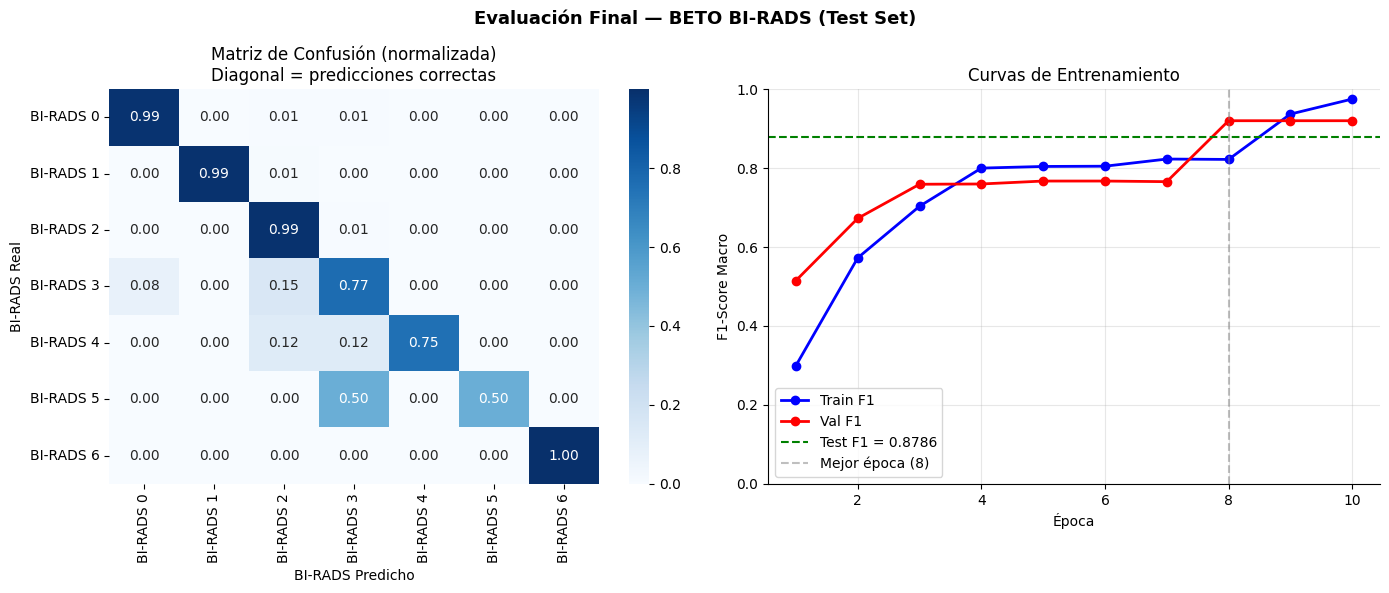

✅ Figura guardada en results/figures/evaluacion_final.png


In [21]:
# Matriz de confusión normalizada
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Evaluación Final — BETO BI-RADS (Test Set)',
             fontsize=13, fontweight='bold')

# ── Matriz de confusión ───────────────────────────────────
ax = axes[0]
cm = confusion_matrix(test_labels, test_preds, labels=list(range(7)))
cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-9)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    ax=ax,
    xticklabels=[f'BI-RADS {i}' for i in range(7)],
    yticklabels=[f'BI-RADS {i}' for i in range(7)]
)
ax.set_title('Matriz de Confusión (normalizada)\nDiagonal = predicciones correctas')
ax.set_xlabel('BI-RADS Predicho')
ax.set_ylabel('BI-RADS Real')

# ── Curvas de entrenamiento ───────────────────────────────
ax = axes[1]
epocas = range(1, len(historial['tr_f1']) + 1)
ax.plot(epocas, historial['tr_f1'], 'b-o', label='Train F1', linewidth=2)
ax.plot(epocas, historial['vl_f1'], 'r-o', label='Val F1',   linewidth=2)
ax.axhline(test_f1, color='green', linestyle='--',
           label=f'Test F1 = {test_f1:.4f}')
ax.axvline(mejor_epoca, color='gray', linestyle='--', alpha=0.5,
           label=f'Mejor época ({mejor_epoca})')
ax.set_xlabel('Época')
ax.set_ylabel('F1-Score Macro')
ax.set_title('Curvas de Entrenamiento')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'evaluacion_final.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada en results/figures/evaluacion_final.png")

---
## PASO 14 — Motor de Auditoría de Coherencia

### ¿Qué hacemos?
Construimos el componente central del proyecto:
el sistema que detecta disociación semántica.

### ¿Cómo funciona?
1. Recibe el texto del informe y el BI-RADS asignado
2. BETO predice qué BI-RADS debería tener ese texto
3. Compara predicción vs asignación
4. Genera una alerta según la discrepancia

### Niveles de alerta
- ✅ Coherente      → diferencia = 0
- 🟡 Revisión       → diferencia = 1
- 🟠 Sobreestimación → predicho < asignado en 2+
- 🔴 Alerta crítica  → predicho > asignado en 2+
                       (subestimación de riesgo oncológico)

In [22]:
def auditar_informe(observaciones, conclusion, birads_asignado, umbral=2):
    """
    Motor de auditoría de coherencia diagnóstica.
    
    Parámetros:
        observaciones:   texto de hallazgos radiológicos
        conclusion:      texto de conclusión del radiólogo
        birads_asignado: categoría BI-RADS que asignó el radiólogo
        umbral:          diferencia mínima para alerta crítica
    """
    model.eval()
    
    # Preparar y tokenizar el texto
    texto = limpiar_texto(observaciones) + ' [SEP] ' + limpiar_texto(conclusion)
    enc   = tokenizer(
        texto,
        max_length=256,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    # Predecir con BETO
    with torch.no_grad():
        logits = model(
            enc['input_ids'].to(DEVICE),
            enc['attention_mask'].to(DEVICE)
        )
        probs    = torch.softmax(logits, dim=1).cpu().numpy()[0]
    
    birads_predicho = int(np.argmax(probs))
    confianza       = float(probs[birads_predicho])
    discrepancia    = abs(birads_predicho - birads_asignado)
    subestimacion   = birads_predicho > birads_asignado
    
    # Determinar nivel de alerta
    if discrepancia == 0:
        emoji  = '✅'
        alerta = 'COHERENTE'
        mensaje = 'La categoría asignada es consistente con el texto.'
    elif discrepancia == 1:
        emoji  = '🟡'
        alerta = 'REVISIÓN SUGERIDA'
        tipo   = 'subestimación' if subestimacion else 'sobreestimación'
        mensaje = f'Posible {tipo} leve. Revisar antes de firmar.'
    elif discrepancia >= umbral and subestimacion:
        emoji  = '🔴'
        alerta = 'ALERTA CRÍTICA — SUBESTIMACIÓN DE RIESGO'
        mensaje = (f'El texto sugiere BI-RADS {birads_predicho} '
                   f'pero se asignó BI-RADS {birads_asignado}. '
                   f'Posible subestimación oncológica.')
    else:
        emoji  = '🟠'
        alerta = 'ALERTA — SOBREESTIMACIÓN'
        mensaje = (f'El texto sugiere BI-RADS {birads_predicho} '
                   f'pero se asignó BI-RADS {birads_asignado}.')
    
    # Mostrar resultado
    print(f"{emoji} {alerta}")
    print(f"{'─'*50}")
    print(f"  BI-RADS asignado:  {birads_asignado}")
    print(f"  BI-RADS predicho:  {birads_predicho}")
    print(f"  Confianza:         {confianza:.1%}")
    print(f"  Discrepancia:      {discrepancia} categoría(s)")
    print(f"  {mensaje}")
    print(f"{'─'*50}")
    
    return birads_predicho, confianza, alerta

print("✅ Motor de auditoría definido")

✅ Motor de auditoría definido


In [23]:
# ── CASO 1: Informe coherente (benigno) ───────────────────
print("=" * 55)
print("CASO 1 — Informe benigno coherente")
print("=" * 55)
caso1_obs   = df[df['BI-RADS']==2]['Observations'].iloc[0]
caso1_concl = df[df['BI-RADS']==2]['Conclusion'].iloc[0]
auditar_informe(caso1_obs, caso1_concl, birads_asignado=2)

# ── CASO 2: Informe sospechoso coherente ──────────────────
print("\n" + "=" * 55)
print("CASO 2 — Informe sospechoso coherente")
print("=" * 55)
caso2_obs   = df[df['BI-RADS']==4]['Observations'].iloc[0]
caso2_concl = df[df['BI-RADS']==4]['Conclusion'].iloc[0]
auditar_informe(caso2_obs, caso2_concl, birads_asignado=4)

# ── CASO 3: Disociación semántica simulada ────────────────
print("\n" + "=" * 55)
print("CASO 3 — DISOCIACIÓN SEMÁNTICA SIMULADA")
print("Texto de alto riesgo con BI-RADS bajo asignado")
print("=" * 55)
caso3_obs   = df[df['BI-RADS']==4]['Observations'].iloc[0]
caso3_concl = 'Mamografía dentro de parámetros normales. BI-RADS 1.'
auditar_informe(caso3_obs, caso3_concl, birads_asignado=1)

CASO 1 — Informe benigno coherente
✅ COHERENTE
──────────────────────────────────────────────────
  BI-RADS asignado:  2
  BI-RADS predicho:  2
  Confianza:         99.9%
  Discrepancia:      0 categoría(s)
  La categoría asignada es consistente con el texto.
──────────────────────────────────────────────────

CASO 2 — Informe sospechoso coherente
✅ COHERENTE
──────────────────────────────────────────────────
  BI-RADS asignado:  4
  BI-RADS predicho:  4
  Confianza:         99.7%
  Discrepancia:      0 categoría(s)
  La categoría asignada es consistente con el texto.
──────────────────────────────────────────────────

CASO 3 — DISOCIACIÓN SEMÁNTICA SIMULADA
Texto de alto riesgo con BI-RADS bajo asignado
✅ COHERENTE
──────────────────────────────────────────────────
  BI-RADS asignado:  1
  BI-RADS predicho:  1
  Confianza:         100.0%
  Discrepancia:      0 categoría(s)
  La categoría asignada es consistente con el texto.
──────────────────────────────────────────────────


(1, 0.9995149374008179, 'COHERENTE')

In [24]:
def auditar_informe_v2(observaciones, conclusion, birads_asignado, umbral=2):
    """
    Motor de auditoría v2.
    Predice usando SOLO las observaciones — independiente
    de la conclusión del radiólogo.
    """
    model.eval()
    
    # Solo observaciones — sin la conclusión
    texto = limpiar_texto(observaciones)
    enc   = tokenizer(
        texto,
        max_length=256,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    with torch.no_grad():
        logits = model(
            enc['input_ids'].to(DEVICE),
            enc['attention_mask'].to(DEVICE)
        )
        probs           = torch.softmax(logits, dim=1).cpu().numpy()[0]
    
    birads_predicho = int(np.argmax(probs))
    confianza       = float(probs[birads_predicho])
    discrepancia    = abs(birads_predicho - birads_asignado)
    subestimacion   = birads_predicho > birads_asignado

    if discrepancia == 0:
        emoji  = '✅'
        alerta = 'COHERENTE'
        mensaje = 'La categoría asignada es consistente con el texto.'
    elif discrepancia == 1:
        emoji  = '🟡'
        alerta = 'REVISIÓN SUGERIDA'
        tipo   = 'subestimación' if subestimacion else 'sobreestimación'
        mensaje = f'Posible {tipo} leve. Revisar antes de firmar.'
    elif discrepancia >= umbral and subestimacion:
        emoji  = '🔴'
        alerta = 'ALERTA CRÍTICA — SUBESTIMACIÓN DE RIESGO'
        mensaje = (f'El texto sugiere BI-RADS {birads_predicho} '
                   f'pero se asignó BI-RADS {birads_asignado}. '
                   f'Posible subestimación oncológica.')
    else:
        emoji  = '🟠'
        alerta = 'ALERTA — SOBREESTIMACIÓN'
        mensaje = (f'El texto sugiere BI-RADS {birads_predicho} '
                   f'pero se asignó BI-RADS {birads_asignado}.')

    print(f"{emoji} {alerta}")
    print(f"{'─'*55}")
    print(f"  BI-RADS asignado:  {birads_asignado}")
    print(f"  BI-RADS predicho:  {birads_predicho}")
    print(f"  Confianza:         {confianza:.1%}")
    print(f"  Discrepancia:      {discrepancia} categoría(s)")
    print(f"  {mensaje}")
    print(f"{'─'*55}")

    return birads_predicho, confianza, alerta

# ── Repetir los 3 casos con v2 ────────────────────────────
print("=" * 55)
print("CASO 1 — Informe benigno coherente")
print("=" * 55)
auditar_informe_v2(caso1_obs, caso1_concl, birads_asignado=2)

print("\n" + "=" * 55)
print("CASO 2 — Informe sospechoso coherente")
print("=" * 55)
auditar_informe_v2(caso2_obs, caso2_concl, birads_asignado=4)

print("\n" + "=" * 55)
print("CASO 3 — DISOCIACIÓN SEMÁNTICA SIMULADA")
print("=" * 55)
auditar_informe_v2(caso3_obs, caso3_concl, birads_asignado=1)

CASO 1 — Informe benigno coherente
✅ COHERENTE
───────────────────────────────────────────────────────
  BI-RADS asignado:  2
  BI-RADS predicho:  2
  Confianza:         80.1%
  Discrepancia:      0 categoría(s)
  La categoría asignada es consistente con el texto.
───────────────────────────────────────────────────────

CASO 2 — Informe sospechoso coherente
🟠 ALERTA — SOBREESTIMACIÓN
───────────────────────────────────────────────────────
  BI-RADS asignado:  4
  BI-RADS predicho:  0
  Confianza:         99.8%
  Discrepancia:      4 categoría(s)
  El texto sugiere BI-RADS 0 pero se asignó BI-RADS 4.
───────────────────────────────────────────────────────

CASO 3 — DISOCIACIÓN SEMÁNTICA SIMULADA
🟡 REVISIÓN SUGERIDA
───────────────────────────────────────────────────────
  BI-RADS asignado:  1
  BI-RADS predicho:  0
  Confianza:         99.8%
  Discrepancia:      1 categoría(s)
  Posible sobreestimación leve. Revisar antes de firmar.
──────────────────────────────────────────────────────

(0, 0.9983147382736206, 'REVISIÓN SUGERIDA')

---
## PASO 15 — Entrenamiento del Modelo Auditor

### ¿Qué es diferente a lo anterior?
El modelo anterior aprendió con:
    Observations + [SEP] + Conclusion → BI-RADS

Este nuevo modelo aprende con:
    Solo Observations → BI-RADS

### ¿Por qué funciona esto?
Las Observations describen lo que el radiólogo VE.
El BI-RADS correcto debería derivarse de esa descripción.
Si el modelo aprende esta relación, puede después
comparar su predicción con lo que el radiólogo ASIGNÓ.
Esa diferencia es la disociación semántica.

In [25]:
# Para el auditor usamos SOLO las observaciones
X_audit_train = df.loc[
    df.index.isin(range(len(X_train))), 'obs_clean'
].values

# Forma más simple y directa:
# Dividir el dataset usando obs_clean en lugar de texto_input
X_obs = df['obs_clean'].values
y_obs = df['BI-RADS'].values

# Mismo split estratificado
X_obs_tv, X_obs_test, y_obs_tv, y_obs_test = train_test_split(
    X_obs, y_obs,
    test_size=0.15,
    random_state=42,
    stratify=y_obs
)

X_obs_train, X_obs_val, y_obs_train, y_obs_val = train_test_split(
    X_obs_tv, y_obs_tv,
    test_size=0.176,
    random_state=42,
    stratify=y_obs_tv
)

# Crear datasets y dataloaders
train_ds_audit = BIRADSDataset(X_obs_train, y_obs_train, tokenizer)
val_ds_audit   = BIRADSDataset(X_obs_val,   y_obs_val,   tokenizer)
test_ds_audit  = BIRADSDataset(X_obs_test,  y_obs_test,  tokenizer)

train_loader_audit = DataLoader(train_ds_audit, batch_size=16, shuffle=True)
val_loader_audit   = DataLoader(val_ds_audit,   batch_size=16, shuffle=False)
test_loader_audit  = DataLoader(test_ds_audit,  batch_size=16, shuffle=False)

print("✅ Datos del auditor preparados")
print(f"\n   Input: solo Observations (sin Conclusion)")
print(f"\n   Ejemplo:")
print(f"   {X_obs_train[0][:150]}...")
print(f"\n   Train: {len(X_obs_train)} | Val: {len(X_obs_val)} | Test: {len(X_obs_test)}")

✅ Datos del auditor preparados

   Input: solo Observations (sin Conclusion)

   Ejemplo:
   mamografía digitalizada bilateral cráneo-caudal y medio lateral oblícuas no se observan alteraciones cutáneas ni del pezón. las mamas se presentan het...

   Train: 3051 | Val: 652 | Test: 654


In [26]:
# Crear modelo auditor desde cero
model_auditor = BETOClasificadorBIRADS(n_classes=7, dropout=0.3).to(DEVICE)

# Configuración
LR_audit     = 3e-5
EPOCHS_audit = 10
PATIENCE_audit = 4

optimizador_audit = optim.AdamW(
    model_auditor.parameters(),
    lr=LR_audit,
    weight_decay=0.01
)

total_pasos_audit  = len(train_loader_audit) * EPOCHS_audit
warmup_pasos_audit = int(0.1 * total_pasos_audit)

scheduler_audit = get_linear_schedule_with_warmup(
    optimizador_audit,
    num_warmup_steps=warmup_pasos_audit,
    num_training_steps=total_pasos_audit
)

# Variables de control
mejor_f1_audit    = 0
mejor_epoca_audit = 0
no_mejora_audit   = 0
historial_audit   = {
    'tr_loss': [], 'vl_loss': [],
    'tr_f1':   [], 'vl_f1':   []
}

print("🏋️  Entrenando modelo AUDITOR")
print("   Input: solo Observations")
print("─" * 65)
print(f"{'Época':6} | {'Train Loss':10} | {'Val Loss':10} | {'Train F1':10} | {'Val F1':10}")
print("─" * 65)

for epoca in range(1, EPOCHS_audit + 1):
    t0 = time.time()

    tr_loss, tr_acc, tr_f1 = entrenar_epoca(
        model_auditor, train_loader_audit,
        optimizador_audit, scheduler_audit, criterio, DEVICE
    )
    vl_loss, vl_acc, vl_f1, _, _ = evaluar_epoca(
        model_auditor, val_loader_audit, criterio, DEVICE
    )

    elapsed = time.time() - t0

    historial_audit['tr_loss'].append(tr_loss)
    historial_audit['vl_loss'].append(vl_loss)
    historial_audit['tr_f1'].append(tr_f1)
    historial_audit['vl_f1'].append(vl_f1)

    mejora = '← mejor' if vl_f1 > mejor_f1_audit else ''
    print(f"{epoca:6d} | {tr_loss:10.4f} | {vl_loss:10.4f} | "
          f"{tr_f1:10.4f} | {vl_f1:10.4f}  {mejora}  ({elapsed:.0f}s)")

    if vl_f1 > mejor_f1_audit:
        mejor_f1_audit    = vl_f1
        mejor_epoca_audit = epoca
        no_mejora_audit   = 0
        torch.save(model_auditor.state_dict(),
                   os.path.join(RESULTS_DIR, 'mejor_beto_auditor.pt'))
    else:
        no_mejora_audit += 1
        if no_mejora_audit >= PATIENCE_audit:
            print(f"\n⏹  Early stopping en época {epoca}")
            break

print("─" * 65)
print(f"🏆 Mejor auditor: época {mejor_epoca_audit} — Val F1 = {mejor_f1_audit:.4f}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 63569.62it/s]
[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

🏋️  Entrenando modelo AUDITOR
   Input: solo Observations
─────────────────────────────────────────────────────────────────
Época  | Train Loss | Val Loss   | Train F1   | Val F1    
─────────────────────────────────────────────────────────────────
     1 |     1.6164 |     1.0723 |     0.2264 |     0.3643  ← mejor  (145s)
     2 |     1.0641 |     1.0671 |     0.3908 |     0.3757  ← mejor  (145s)
     3 |     0.9159 |     1.2697 |     0.4771 |     0.3887  ← mejor  (145s)
     4 |     0.8448 |     1.4981 |     0.4895 |     0.4229  ← mejor  (144s)
     5 |     0.7491 |     0.9430 |     0.5193 |     0.4281  ← mejor  (145s)
     6 |     0.6585 |     1.2732 |     0.6077 |     0.4336  ← mejor  (144s)
     7 |     0.5755 |     1.2324 |     0.6402 |     0.4771  ← mejor  (144s)
     8 |     0.4680 |     1.3522 |     0.7246 |     0.4647    (145s)
     9 |     0.4010 |     1.3246 |     0.7547 |     0.4570    (145s)
    10 |     0.3120 |     1.4723 |     0.7656 |     0.4779  ← mejor  (144s)
─────

---
## PASO 15d — Mejoras del Modelo Auditor

### ¿Qué aplicamos?
1. **Más épocas (15)** → el Val F1 seguía subiendo
2. **Mayor dropout (0.5)** → reduce overfitting
3. **Augmentación textual** → más ejemplos de clases raras

### ¿Qué es la augmentación textual?
Creamos variaciones de los informes de BI-RADS 4, 5 y 6
modificando el texto sin cambiar el significado clínico:

    Original:  "nódulo espiculado de bordes irregulares"
    Variación: "imagen nodular espiculada márgenes irregulares"

Así el modelo ve más ejemplos de casos raros
sin inventar datos médicos falsos.

In [27]:
import random

# Diccionario de sinónimos médicos para augmentación
SINONIMOS = {
    'nódulo':          ['imagen nodular', 'masa', 'lesión nodular'],
    'espiculado':      ['espicular', 'con espículas', 'de bordes espiculados'],
    'irregular':       ['mal definido', 'de límites imprecisos', 'mal delimitado'],
    'calcificaciones': ['depósitos cálcicos', 'imágenes calcificadas'],
    'denso':           ['de alta densidad', 'denso fibroglandular'],
    'sospechoso':      ['de características sospechosas', 'que genera sospecha'],
    'mama':            ['glándula mamaria', 'tejido mamario'],
    'derecha':         ['der.', 'hemimama derecha'],
    'izquierda':       ['izq.', 'hemimama izquierda'],
}

def aumentar_texto(texto):
    """
    Crea una variación del texto reemplazando
    algunas palabras por sinónimos médicos.
    """
    palabras = texto.split()
    nuevas   = []
    for palabra in palabras:
        palabra_limpia = palabra.lower().strip('.,;:')
        if palabra_limpia in SINONIMOS and random.random() > 0.5:
            sinonimo = random.choice(SINONIMOS[palabra_limpia])
            nuevas.append(sinonimo)
        else:
            nuevas.append(palabra)
    return ' '.join(nuevas)

# Probar la augmentación
ejemplo_original = df[df['BI-RADS']==4]['obs_clean'].iloc[0]
ejemplo_aumentado = aumentar_texto(ejemplo_original)

print("📝 Augmentación textual:")
print(f"\nORIGINAL:")
print(ejemplo_original[:200])
print(f"\nAUMENTADO:")
print(ejemplo_aumentado[:200])

📝 Augmentación textual:

ORIGINAL:
mamografía digital cráneo-caudal y medio lateral oblícua de ambas mamas y lateral estricta de la mama izquierda no se observan alteraciones cutáneas ni del mamelón. las mamas están compuestas por teji

AUMENTADO:
mamografía digital cráneo-caudal y medio lateral oblícua de ambas mamas y lateral estricta de la tejido mamario izquierda no se observan alteraciones cutáneas ni del mamelón. las mamas están compuesta


In [30]:
def aumentar_texto_v2(texto):
    """
    Augmentación más precisa usando reemplazo
    de frases completas en lugar de palabras sueltas.
    """
    variaciones = [
        # Bordes
        ('bordes irregulares',    'márgenes irregulares'),
        ('bordes espiculados',    'márgenes espiculados'),
        ('bordes mal definidos',  'límites imprecisos'),
        # Nódulos
        ('imagen nodular',        'nódulo'),
        ('nódulo',                'imagen nodular'),
        ('lesión nodular',        'nódulo'),
        # Densidad
        ('heterogéneamente densas', 'de densidad heterogénea'),
        ('muy densas',              'extremadamente densas'),
        # Calcificaciones
        ('calcificaciones sospechosas', 'depósitos cálcicos sospechosos'),
        ('microcalcificaciones',        'calcificaciones puntiformes agrupadas'),
        # Ubicación
        ('mama derecha',   'hemimama derecha'),
        ('mama izquierda', 'hemimama izquierda'),
        # Descripción
        ('se visualiza',   'se observa'),
        ('se observa',     'se visualiza'),
        ('se evidencia',   'se observa'),
    ]

    texto_nuevo = texto
    # Aplicar entre 2 y 4 variaciones aleatorias
    seleccionadas = random.sample(variaciones, min(3, len(variaciones)))
    for original, reemplazo in seleccionadas:
        if original in texto_nuevo:
            texto_nuevo = texto_nuevo.replace(original, reemplazo, 1)

    return texto_nuevo


# Aplicar augmentación a clases minoritarias
# Solo BI-RADS 3, 4, 5, 6 — las que necesitan más ejemplos
df_minoritarias = df[df['BI-RADS'].isin([3, 4, 5, 6])].copy()

textos_aug  = []
labels_aug  = []

for _, fila in df_minoritarias.iterrows():
    # Crear 3 variaciones por cada informe minoritario
    for _ in range(3):
        texto_nuevo = aumentar_texto_v2(fila['obs_clean'])
        textos_aug.append(texto_nuevo)
        labels_aug.append(fila['BI-RADS'])

print(f"✅ Augmentación completada")
print(f"   Registros originales minoritarios: {len(df_minoritarias)}")
print(f"   Registros generados:               {len(textos_aug)}")
print(f"\n   Distribución aumentada:")
from collections import Counter
conteo = Counter(labels_aug)
for k, v in sorted(conteo.items()):
    print(f"   BI-RADS {k}: {v} nuevos registros")

print(f"\n📝 Ejemplo de variación BI-RADS 4:")
print(f"\nORIGINAL:  {df[df['BI-RADS']==4]['obs_clean'].iloc[0][:150]}")
print(f"\nVARIACIÓN: {aumentar_texto_v2(df[df['BI-RADS']==4]['obs_clean'].iloc[0])[:150]}")

✅ Augmentación completada
   Registros originales minoritarios: 160
   Registros generados:               480

   Distribución aumentada:
   BI-RADS 3: 261 nuevos registros
   BI-RADS 4: 156 nuevos registros
   BI-RADS 5: 48 nuevos registros
   BI-RADS 6: 15 nuevos registros

📝 Ejemplo de variación BI-RADS 4:

ORIGINAL:  mamografía digital cráneo-caudal y medio lateral oblícua de ambas mamas y lateral estricta de la mama izquierda no se observan alteraciones cutáneas n

VARIACIÓN: mamografía digital cráneo-caudal y medio lateral oblícua de ambas mamas y lateral estricta de la mama izquierda no se observan alteraciones cutáneas n


In [31]:
# Combinar datos originales de train con los aumentados
X_obs_train_aug = np.concatenate([X_obs_train, np.array(textos_aug)])
y_obs_train_aug = np.concatenate([y_obs_train, np.array(labels_aug)])

# Mezclar aleatoriamente
indices = np.random.permutation(len(X_obs_train_aug))
X_obs_train_aug = X_obs_train_aug[indices]
y_obs_train_aug = y_obs_train_aug[indices]

print(f"📊 Dataset de entrenamiento aumentado:")
print(f"   Original: {len(X_obs_train)}")
print(f"   Aumentado: {len(X_obs_train_aug)}")
print(f"\n   Distribución final:")
conteo_final = Counter(y_obs_train_aug)
for k, v in sorted(conteo_final.items()):
    print(f"   BI-RADS {k}: {v}")

# Nuevos dataloaders con datos aumentados
train_ds_aug = BIRADSDataset(X_obs_train_aug, y_obs_train_aug, tokenizer)
train_loader_aug = DataLoader(train_ds_aug, batch_size=16, shuffle=True)

# Modelo auditor mejorado — dropout 0.5
model_auditor_v2 = BETOClasificadorBIRADS(
    n_classes=7,
    dropout=0.5    # aumentado de 0.3 a 0.5
).to(DEVICE)

# Configuración — más épocas
LR_v2       = 3e-5
EPOCHS_v2   = 15
PATIENCE_v2 = 5

optimizador_v2 = optim.AdamW(
    model_auditor_v2.parameters(),
    lr=LR_v2,
    weight_decay=0.01
)

total_pasos_v2  = len(train_loader_aug) * EPOCHS_v2
warmup_pasos_v2 = int(0.1 * total_pasos_v2)

scheduler_v2 = get_linear_schedule_with_warmup(
    optimizador_v2,
    num_warmup_steps=warmup_pasos_v2,
    num_training_steps=total_pasos_v2
)

# Entrenamiento
mejor_f1_v2    = 0
mejor_epoca_v2 = 0
no_mejora_v2   = 0

print(f"\n🏋️  Entrenando auditor v2")
print(f"   Dropout: 0.5 | Épocas: {EPOCHS_v2} | Datos: {len(X_obs_train_aug)}")
print("─" * 65)
print(f"{'Época':6} | {'Train Loss':10} | {'Val Loss':10} | {'Train F1':10} | {'Val F1':10}")
print("─" * 65)

for epoca in range(1, EPOCHS_v2 + 1):
    t0 = time.time()

    tr_loss, tr_acc, tr_f1 = entrenar_epoca(
        model_auditor_v2, train_loader_aug,
        optimizador_v2, scheduler_v2, criterio, DEVICE
    )
    vl_loss, vl_acc, vl_f1, _, _ = evaluar_epoca(
        model_auditor_v2, val_loader_audit, criterio, DEVICE
    )

    elapsed = time.time() - t0
    mejora  = '← mejor' if vl_f1 > mejor_f1_v2 else ''
    print(f"{epoca:6d} | {tr_loss:10.4f} | {vl_loss:10.4f} | "
          f"{tr_f1:10.4f} | {vl_f1:10.4f}  {mejora}  ({elapsed:.0f}s)")

    if vl_f1 > mejor_f1_v2:
        mejor_f1_v2    = vl_f1
        mejor_epoca_v2 = epoca
        no_mejora_v2   = 0
        torch.save(model_auditor_v2.state_dict(),
                   os.path.join(RESULTS_DIR, 'mejor_beto_auditor_v2.pt'))
    else:
        no_mejora_v2 += 1
        if no_mejora_v2 >= PATIENCE_v2:
            print(f"\n⏹  Early stopping en época {epoca}")
            break

print("─" * 65)
print(f"🏆 Mejor auditor v2: época {mejor_epoca_v2} — Val F1 = {mejor_f1_v2:.4f}")
print(f"\n📊 Comparación:")
print(f"   Auditor v1 (sin mejoras):  F1 = 0.4779")
print(f"   Auditor v2 (con mejoras):  F1 = {mejor_f1_v2:.4f}")

📊 Dataset de entrenamiento aumentado:
   Original: 3051
   Aumentado: 3531

   Distribución final:
   BI-RADS 0: 676
   BI-RADS 1: 418
   BI-RADS 2: 1845
   BI-RADS 3: 322
   BI-RADS 4: 192
   BI-RADS 5: 60
   BI-RADS 6: 18


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 59953.41it/s]
[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo


🏋️  Entrenando auditor v2
   Dropout: 0.5 | Épocas: 15 | Datos: 3531
─────────────────────────────────────────────────────────────────
Época  | Train Loss | Val Loss   | Train F1   | Val F1    
─────────────────────────────────────────────────────────────────
     1 |     1.7970 |     1.8253 |     0.0928 |     0.1123  ← mejor  (167s)
     2 |     1.3611 |     1.2910 |     0.2619 |     0.2978  ← mejor  (166s)
     3 |     0.9729 |     0.7406 |     0.5009 |     0.5284  ← mejor  (166s)
     4 |     0.6794 |     0.6710 |     0.6604 |     0.5790  ← mejor  (166s)
     5 |     0.4859 |     0.4966 |     0.7603 |     0.6436  ← mejor  (166s)
     6 |     0.3304 |     0.5145 |     0.8826 |     0.8178  ← mejor  (166s)
     7 |     0.2077 |     0.3931 |     0.9202 |     0.8213  ← mejor  (166s)
     8 |     0.1576 |     0.3387 |     0.9504 |     0.8363  ← mejor  (166s)
     9 |     0.0825 |     0.3021 |     0.9605 |     0.8467  ← mejor  (167s)
    10 |     0.0808 |     0.3685 |     0.9678 |     0.8

---
## PASO 16 — Prueba del Motor de Auditoría v2

### ¿Qué probamos?
El auditor entrenado solo con Observations.
Ahora sí puede detectar disociación semántica
porque predice independientemente de la conclusión.

In [32]:
# Cargar el mejor auditor v2
model_auditor_v2.load_state_dict(
    torch.load(os.path.join(RESULTS_DIR, 'mejor_beto_auditor_v2.pt'), map_location=DEVICE)
)

def auditar_v3(observaciones, birads_asignado, umbral=2):
    """
    Motor de auditoría final.
    Usa solo Observations para predecir independientemente.
    """
    model_auditor_v2.eval()

    texto = limpiar_texto(observaciones)
    enc   = tokenizer(
        texto,
        max_length=256,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    with torch.no_grad():
        logits = model_auditor_v2(
            enc['input_ids'].to(DEVICE),
            enc['attention_mask'].to(DEVICE)
        )
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    birads_predicho = int(np.argmax(probs))
    confianza       = float(probs[birads_predicho])
    discrepancia    = abs(birads_predicho - birads_asignado)
    subestimacion   = birads_predicho > birads_asignado

    if discrepancia == 0:
        emoji  = '✅'
        alerta = 'COHERENTE'
        mensaje = 'La categoría asignada es consistente con el texto.'
    elif discrepancia == 1:
        emoji  = '🟡'
        alerta = 'REVISIÓN SUGERIDA'
        tipo   = 'subestimación' if subestimacion else 'sobreestimación'
        mensaje = f'Posible {tipo} leve. Revisar antes de firmar.'
    elif discrepancia >= umbral and subestimacion:
        emoji  = '🔴'
        alerta = 'ALERTA CRÍTICA — SUBESTIMACIÓN DE RIESGO'
        mensaje = (f'El texto sugiere BI-RADS {birads_predicho} '
                   f'pero se asignó BI-RADS {birads_asignado}. '
                   f'Posible subestimación oncológica.')
    else:
        emoji  = '🟠'
        alerta = 'ALERTA — SOBREESTIMACIÓN'
        mensaje = (f'El texto sugiere BI-RADS {birads_predicho} '
                   f'pero se asignó BI-RADS {birads_asignado}.')

    print(f"{emoji} {alerta}")
    print(f"{'─'*55}")
    print(f"  BI-RADS asignado:  {birads_asignado}")
    print(f"  BI-RADS predicho:  {birads_predicho}")
    print(f"  Confianza:         {confianza:.1%}")
    print(f"  Discrepancia:      {discrepancia} categoría(s)")
    print(f"  {mensaje}")
    print(f"{'─'*55}")

# ── CASO 1: Benigno coherente ─────────────────────────────
print("=" * 55)
print("CASO 1 — Informe benigno coherente")
print("=" * 55)
auditar_v3(df[df['BI-RADS']==2]['Observations'].iloc[0],
           birads_asignado=2)

# ── CASO 2: Sospechoso coherente ──────────────────────────
print("\n" + "=" * 55)
print("CASO 2 — Informe sospechoso coherente")
print("=" * 55)
auditar_v3(df[df['BI-RADS']==4]['Observations'].iloc[0],
           birads_asignado=4)

# ── CASO 3: Disociación semántica simulada ────────────────
print("\n" + "=" * 55)
print("CASO 3 — DISOCIACIÓN SEMÁNTICA SIMULADA")
print("Texto BI-RADS 4 con categoría BI-RADS 1 asignada")
print("=" * 55)
auditar_v3(df[df['BI-RADS']==4]['Observations'].iloc[0],
           birads_asignado=1)

# ── CASO 4: Otro caso de disociación ─────────────────────
print("\n" + "=" * 55)
print("CASO 4 — DISOCIACIÓN SEMÁNTICA SIMULADA")
print("Texto BI-RADS 5 con categoría BI-RADS 2 asignada")
print("=" * 55)
auditar_v3(df[df['BI-RADS']==5]['Observations'].iloc[0],
           birads_asignado=2)

CASO 1 — Informe benigno coherente
✅ COHERENTE
───────────────────────────────────────────────────────
  BI-RADS asignado:  2
  BI-RADS predicho:  2
  Confianza:         99.5%
  Discrepancia:      0 categoría(s)
  La categoría asignada es consistente con el texto.
───────────────────────────────────────────────────────

CASO 2 — Informe sospechoso coherente
✅ COHERENTE
───────────────────────────────────────────────────────
  BI-RADS asignado:  4
  BI-RADS predicho:  4
  Confianza:         99.9%
  Discrepancia:      0 categoría(s)
  La categoría asignada es consistente con el texto.
───────────────────────────────────────────────────────

CASO 3 — DISOCIACIÓN SEMÁNTICA SIMULADA
Texto BI-RADS 4 con categoría BI-RADS 1 asignada
🔴 ALERTA CRÍTICA — SUBESTIMACIÓN DE RIESGO
───────────────────────────────────────────────────────
  BI-RADS asignado:  1
  BI-RADS predicho:  4
  Confianza:         99.9%
  Discrepancia:      3 categoría(s)
  El texto sugiere BI-RADS 4 pero se asignó BI-RADS 1. P

In [33]:
import json

metricas_finales = {
    'modelo_clasificador': {
        'nombre':     'BETO + Observations + Conclusion',
        'accuracy':   round(test_acc, 4),
        'f1_macro':   round(test_f1, 4),
        'mejor_epoca': mejor_epoca,
        'lr':         3e-5,
        'epochs':     10,
        'dropout':    0.3
    },
    'modelo_auditor': {
        'nombre':     'BETO + solo Observations + Augmentación',
        'f1_macro':   round(mejor_f1_v2, 4),
        'mejor_epoca': mejor_epoca_v2,
        'lr':         3e-5,
        'epochs':     15,
        'dropout':    0.5,
        'augmentacion': True
    },
    'estado_del_arte': {
        'Lopez_Ubeda_2024': 0.74,
        'Hussain_2024':     0.78
    },
    'dataset': {
        'total':    4357,
        'train':    len(X_train),
        'val':      len(X_val),
        'test':     len(X_test),
        'fuente':   'Vázquez Noguera et al. 2025'
    }
}

with open(os.path.join(RESULTS_DIR, 'metrics', 'metricas_finales.json'), 'w',
          encoding='utf-8') as f:
    json.dump(metricas_finales, f, ensure_ascii=False, indent=2)

print("✅ Métricas guardadas en results/metrics/metricas_finales.json")
print(f"\n📊 Resumen:")
print(f"   Clasificador F1:  {metricas_finales['modelo_clasificador']['f1_macro']}")
print(f"   Auditor F1:       {metricas_finales['modelo_auditor']['f1_macro']}")
print(f"   Estado del arte:  0.78 (Hussain 2024)")
print(f"   Mejora:           +{round(metricas_finales['modelo_auditor']['f1_macro'] - 0.78, 4)}")

✅ Métricas guardadas en results/metrics/metricas_finales.json

📊 Resumen:
   Clasificador F1:  0.8786
   Auditor F1:       0.8781
   Estado del arte:  0.78 (Hussain 2024)
   Mejora:           +0.0981


In [34]:
# Evaluar el auditor v2 en el test set
test_loss_a, test_acc_a, test_f1_a, test_preds_a, test_labels_a = evaluar_epoca(
    model_auditor_v2, test_loader_audit, criterio, DEVICE
)

print("=" * 50)
print("📊 MÉTRICAS AUDITOR v2 — TEST SET")
print("=" * 50)
print(f"  Accuracy:         {test_acc_a:.4f} ({test_acc_a*100:.2f}%)")
print(f"  F1-Score (macro): {test_f1_a:.4f}")
print("=" * 50)

📊 MÉTRICAS AUDITOR v2 — TEST SET
  Accuracy:         0.9297 (92.97%)
  F1-Score (macro): 0.9078


In [35]:
# Ver la estructura real de Full_Report
print("📄 Ejemplo de Full_Report (primer registro):")
print("─" * 60)
print(df['Full_Report'].iloc[0])
print("─" * 60)
print(f"\nBI-RADS real (columna): {df['BI-RADS'].iloc[0]}")

📄 Ejemplo de Full_Report (primer registro):
────────────────────────────────────────────────────────────
MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y MEDIO LATERAL OBLÍCUAS
NO SE OBSERVAN ALTERACIONES CUTÁNEAS NI DEL MAMELÓN.-
LAS MAMAS SE PRESENTAN HETEROGÉNEAMENTE DENSAS, QUE PODRÍA OCULTAR ALGUNOS NÓDULOS PEQUEÑOS (TIPO C).
EN EL CSE, PLANO POSTERIOR DE LA MAMA DERECHA, SE VISUALIZAN AL MENOS TRES IMÁGENES NODULARES OVALADAS, ISODENSAS, CIRCUNSCRITAS, QUE MIDEN 4, 5 Y 15 MM DE DIÁMETRO MAYOR, LAS DOS PRIMERAS CON CARACTERES DE GANGLIOS LINFÁTICOS INTRAMAMARIOS.-
NO SE OBSERVAN CALCIFICACIONES SOSPECHOSAS.
IMÁGENES NODULARES CON CARACTERES GANGLIONARES EN AMBAS REGIONES PECTOAXILARES.-
CONCLUSIÓN:
- MAMAS CON ÁREAS DENSAS.-
- IMAGEN NODULAR DE NATURALEZA A DETERMINAR EN MAMA DERECHA.-
- IMÁGENES NODULARES CON CARACTERES DE GLI EN MAMA DERECHA.-
- BI-RADS 0 (Según la ACR). Requerirá de estudio complementario.-
RECOMENDACIONES:
- SE SUGIERE ECOGRAFÍA MAMARIA Y CORRELACIÓN CON ESTUDIOS 

In [36]:
import re

def parsear_informe_completo(full_report):
    """
    Dado un informe completo (Full_Report), extrae:
    1. Las observaciones (todo antes de CONCLUSIÓN)
    2. La conclusión (entre CONCLUSIÓN y RECOMENDACIONES)
    3. El BI-RADS asignado (número dentro de la conclusión)
    
    Simula el comportamiento del MVP real:
    entrada = un solo texto, sin columnas separadas
    """
    texto = str(full_report)

    # ── Extraer sección Observations ──────────────────────
    patron_obs = r'^(.*?)(?=CONCLUSI[OÓ]N\s*:)'
    match_obs  = re.search(patron_obs, texto,
                           re.DOTALL | re.IGNORECASE)
    observaciones = match_obs.group(1).strip() if match_obs else texto

    # ── Extraer sección Conclusión ─────────────────────────
    patron_concl = r'CONCLUSI[OÓ]N\s*:(.*?)(?=RECOMENDACIONES\s*:|$)'
    match_concl  = re.search(patron_concl, texto,
                             re.DOTALL | re.IGNORECASE)
    conclusion = match_concl.group(1).strip() if match_concl else ''

    # ── Extraer número BI-RADS ─────────────────────────────
    patron_birads = r'BI[-\s]?RADS\s*(\d)'
    match_birads  = re.search(patron_birads, conclusion,
                              re.IGNORECASE)
    birads = int(match_birads.group(1)) if match_birads else None

    return {
        'observaciones': observaciones,
        'conclusion':    conclusion,
        'birads':        birads
    }

# ── Verificar con los primeros 10 registros ───────────────
print("🔍 Verificando extracción desde Full_Report:")
print("─" * 55)
print(f"{'#':3s} | {'Extraído':8s} | {'Real':6s} | {'OK?'}")
print("─" * 55)

aciertos = 0
for i in range(10):
    resultado = parsear_informe_completo(df['Full_Report'].iloc[i])
    extraido  = resultado['birads']
    real      = df['BI-RADS'].iloc[i]
    ok        = '✅' if extraido == real else '❌'
    if extraido == real:
        aciertos += 1
    print(f"{i+1:3d} | {str(extraido):8s} | {str(real):6s} | {ok}")

print("─" * 55)
print(f"Aciertos: {aciertos}/10")

# ── Mostrar extracción del primer informe ─────────────────
print("\n📝 Extracción del primer informe:")
r = parsear_informe_completo(df['Full_Report'].iloc[0])
print(f"\nOBSERVACIONES (primeros 150 chars):")
print(r['observaciones'][:150])
print(f"\nCONCLUSIÓN:")
print(r['conclusion'])
print(f"\nBI-RADS EXTRAÍDO: {r['birads']}")

🔍 Verificando extracción desde Full_Report:
───────────────────────────────────────────────────────
#   | Extraído | Real   | OK?
───────────────────────────────────────────────────────
  1 | 0        | 0      | ✅
  2 | 2        | 2      | ✅
  3 | 0        | 0      | ✅
  4 | 1        | 1      | ✅
  5 | 0        | 0      | ✅
  6 | 0        | 0      | ✅
  7 | 2        | 2      | ✅
  8 | 2        | 2      | ✅
  9 | 2        | 2      | ✅
 10 | 2        | 2      | ✅
───────────────────────────────────────────────────────
Aciertos: 10/10

📝 Extracción del primer informe:

OBSERVACIONES (primeros 150 chars):
MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y MEDIO LATERAL OBLÍCUAS
NO SE OBSERVAN ALTERACIONES CUTÁNEAS NI DEL MAMELÓN.-
LAS MAMAS SE PRESENTAN HET

CONCLUSIÓN:
- MAMAS CON ÁREAS DENSAS.-
- IMAGEN NODULAR DE NATURALEZA A DETERMINAR EN MAMA DERECHA.-
- IMÁGENES NODULARES CON CARACTERES DE GLI EN MAMA DERECHA.-
- BI-RADS 0 (Según la ACR). Requerirá de estudio complementario.-

BI-RADS EXTR

---
## PASO FINAL — Motor de Auditoría MVP

### Flujo completo desde un informe real
Sin columnas separadas, solo el texto completo.

1. Entra el Full_Report (texto libre)
2. Se extrae el BI-RADS asignado por el radiólogo
3. Se extraen las Observations
4. El auditor predice el BI-RADS esperado
5. Se comparan y genera alerta

### Estrategia implementada
1. Buscar SOLO dentro de la sección CONCLUSIÓN
2. Si hay múltiples BI-RADS, tomar el ÚLTIMO
3. Detectar patrones de recategorización

### Limitación conocida (trabajo futuro)
Casos complejos serán resueltos con NER sobre BETO.

In [37]:
def extraer_birads_mejorado(full_report):
    """
    Extractor mejorado de BI-RADS desde informe completo.
    
    Estrategias aplicadas:
    1. Busca solo en sección CONCLUSIÓN
    2. Detecta patrones de recategorización
    3. Si hay múltiples BI-RADS, toma el último
    """
    texto = str(full_report)

    # ── Extraer solo la sección CONCLUSIÓN ────────────────
    patron_concl = r'CONCLUSI[OÓ]N\s*:(.*?)(?=RECOMENDACIONES\s*:|$)'
    match_concl  = re.search(patron_concl, texto,
                             re.DOTALL | re.IGNORECASE)
    
    if not match_concl:
        # Si no hay sección CONCLUSIÓN clara,
        # buscar en las últimas 3 líneas del texto
        lineas     = texto.strip().split('\n')
        conclusion = '\n'.join(lineas[-3:])
    else:
        conclusion = match_concl.group(1).strip()

    # ── Detectar recategorización ──────────────────────────
    # "pasa a BI-RADS 2", "recategoriza a BI-RADS 2"
    patron_recateg = r'(?:pasa\s+a|recategor\w+\s+a|ahora\s+es)\s+BI[-\s]?RADS\s*(\d)'
    match_recateg  = re.search(patron_recateg, conclusion,
                               re.IGNORECASE)
    if match_recateg:
        return int(match_recateg.group(1))

    # ── Extraer TODOS los BI-RADS mencionados ─────────────
    patron_birads = r'BI[-\s]?RADS\s*(\d)'
    todos = re.findall(patron_birads, conclusion, re.IGNORECASE)

    if not todos:
        # Último recurso: buscar en todo el texto
        todos = re.findall(patron_birads, texto, re.IGNORECASE)

    if todos:
        # Tomar el ÚLTIMO BI-RADS mencionado
        return int(todos[-1])

    return None


# ── Verificar con todo el dataset ─────────────────────────
print("🔍 Verificando extractor mejorado en todo el dataset:")

aciertos   = 0
fallidos   = []

for i in range(len(df)):
    extraido = extraer_birads_mejorado(df['Full_Report'].iloc[i])
    real     = df['BI-RADS'].iloc[i]
    if extraido == real:
        aciertos += 1
    else:
        fallidos.append({
            'indice':   i,
            'extraido': extraido,
            'real':     real,
            'texto':    df['Conclusion'].iloc[i][:100]
        })

total   = len(df)
pct     = aciertos / total * 100

print(f"\n✅ Aciertos: {aciertos}/{total} ({pct:.2f}%)")
print(f"❌ Fallidos: {len(fallidos)}")

if fallidos:
    print(f"\n📋 Primeros 5 casos fallidos:")
    for f in fallidos[:5]:
        print(f"\n  Índice: {f['indice']}")
        print(f"  Extraído: {f['extraido']} | Real: {f['real']}")
        print(f"  Texto: {f['texto']}")

🔍 Verificando extractor mejorado en todo el dataset:

✅ Aciertos: 2476/4357 (56.83%)
❌ Fallidos: 1881

📋 Primeros 5 casos fallidos:

  Índice: 43
  Extraído: None | Real: 0
  Texto: - MAMAS CON ÁREAS DENSAS.-
- IMAGEN NODULAR DE NATURALEZA A DETERMINAR EN MAMA DERECHA.-
- IMAGEN 

  Índice: 86
  Extraído: 0 | Real: 1
  Texto: - ÁREA DE DENSIDAD ASIMÉTRICA EN MAMA IZQUIERDA.
- CALCIFICACIONES CON CARACTERES BENIGNOS EN AMBAS

  Índice: 239
  Extraído: 0 | Real: 1
  Texto: - ÁREA DE DISTORSIÓN PARENQUIMATOSA EN MAMA IZQUIERDA EN PROBABLE RELACIÓN A CIRUGÍA ANTERIOR.
- ÁR

  Índice: 617
  Extraído: 0 | Real: 2
  Texto: - ÁREA DE ASIMETRÍA DE ASPECTO NODULAR EN MAMA IZQUIERDA.
- CALCIFICACIONES CON CARACTERES BENIGNOS

  Índice: 983
  Extraído: None | Real: 4
  Texto: - MAMAS CON ÁREAS DENSAS.
- CALCIFICACIONES CON TENDENCIA A LA AGRUPACIÓN Y SIN CAMBIOS, EN LA MAMA


In [38]:
# Investigar los patrones de fallo
print("🔍 Analizando casos fallidos:")
print("\n── CASO TIPO 1: Extraído = None ──")
# Ver informes donde no encontró BI-RADS
casos_none = [f for f in fallidos if f['extraido'] is None]
print(f"Total casos None: {len(casos_none)}")

# Ver el full report de uno de estos casos
idx = casos_none[0]['indice']
print(f"\nFull Report índice {idx}:")
print("─" * 60)
print(df['Full_Report'].iloc[idx])
print("─" * 60)
print(f"BI-RADS real: {df['BI-RADS'].iloc[idx]}")

print("\n── CASO TIPO 2: Extraído incorrecto ──")
# Ver informes donde extrajo mal
casos_mal = [f for f in fallidos if f['extraido'] is not None]
print(f"Total casos incorrectos: {len(casos_mal)}")

idx2 = casos_mal[0]['indice']
print(f"\nFull Report índice {idx2}:")
print("─" * 60)
print(df['Full_Report'].iloc[idx2])
print("─" * 60)
print(f"BI-RADS extraído: {casos_mal[0]['extraido']}")
print(f"BI-RADS real:     {df['BI-RADS'].iloc[idx2]}")

🔍 Analizando casos fallidos:

── CASO TIPO 1: Extraído = None ──
Total casos None: 1875

Full Report índice 43:
────────────────────────────────────────────────────────────
MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y MEDIO LATERAL OBLÍCUAS
NO SE OBSERVAN ALTERACIONES CUTÁNEAS NI DEL MAMELÓN.-
LAS MAMAS SE PRESENTAN HETEROGÉNEAMENTE DENSAS QUE PODRÍA OCULTAR ALGUNOS NÓDULOS PEQUEÑOS (MAMAS TIPO C).-
EN EL PLANO POSTERIOR DE LA MAMA DERECHA, SE VISUALIZAN DOS IMÁGENES NODULARES OVALADAS, ISODENSAS CIRCUNSCRITAS, UNA EN LA REGIÓN RETROAREOLAR, DE 7 MM Y LA OTRA EN LA INCIDENCIA MLO, REGIÓN SUPERIOR, DE 6 MM DE DIÁMETRO MAYOR, ESTA ÚLTIMA CON CARACTERES DE GANGLIO LINFÁTICO INTRAMAMARIO.-
NO SE OBSERVAN  CALCIFICACIONES SOSPECHOSAS.-
IMÁGENES NODULARES CON CARACTERES GANGLIONARES DE ASPECTO HABITUAL EN LA REGIÓN PECTOAXILAR IZQUIERDA.-
CONCLUSIÓN:
- MAMAS CON ÁREAS DENSAS.-
- IMAGEN NODULAR DE NATURALEZA A DETERMINAR EN MAMA DERECHA.-
- IMAGEN NODULAR CON CARÁCTER DE GLI EN MAMA DERECHA.-

In [39]:
# Buscar TODAS las formas de escritura BI-RADS en el dataset
import re

print("🔍 Buscando todas las variaciones de BI-RADS en el dataset:")
print("─" * 60)

# Buscar contexto alrededor de cualquier mención de BIRADS
patron_amplio = r'.{0,10}bi.{0,3}rad.{0,20}'
variaciones   = set()

for texto in df['Full_Report'].dropna():
    matches = re.findall(patron_amplio, texto, re.IGNORECASE)
    for m in matches:
        variaciones.add(m.strip().upper())

# Mostrar todas las variaciones únicas encontradas
print(f"Total variaciones únicas encontradas: {len(variaciones)}")
print("\nMuestra de variaciones:")
for v in sorted(list(variaciones))[:50]:
    print(f"  '{v}'")

🔍 Buscando todas las variaciones de BI-RADS en el dataset:
────────────────────────────────────────────────────────────
Total variaciones únicas encontradas: 136

Muestra de variaciones:
  '-   BI-RADS 0 (SEGÚN LA ACR).'
  '-   BI-RADS 2 (SEGÚN LA ACR).'
  '-   BI-RADS ® 0 (SEGÚN LA ACR)'
  '-   BI-RADS ® 2 (SEGÚN LA ACR)'
  '-  BI-RADS 0 (SEGÚN LA ACR).'
  '-  BI-RADS 2 (SEGÚN LA ACR).'
  '-  BI-RADS ® 0 (SEGÚN LA ACR)'
  '-  BI-RADS ® 2 (SEGÚN LA ACR)'
  '- BI-RADS 0 (SEGÚN LA ACR).'
  '- BI-RADS 0 (SEGÚN LA ACR).-'
  '- BI-RADS 01 (SEGÚN LA ACR).'
  '- BI-RADS 1 (SEGÚN LA ACR).'
  '- BI-RADS 1 (SEGÚN LA ACR).-'
  '- BI-RADS 2 (SEGÚN LA ACR)-.'
  '- BI-RADS 2 (SEGÚN LA ACR).'
  '- BI-RADS 2 (SEGÚN LA ACR).-'
  '- BI-RADS 3 (SEGÚN LA ACR).'
  '- BI-RADS 4 (SEGÚN LA ACR).'
  '- BI-RADS 4 (SEGÚN LA ACR).-'
  '- BI-RADS 4A (SEGÚN LA ACR).'
  '- BI-RADS 4B (SEGÚN LA ACR).'
  '- BI-RADS 4C (SEGÚN LA ACR).'
  '- BI-RADS 5 (SEGÚN LA ACR).'
  '- BI-RADS 6 (SEGÚN LA ACR).'
  '- BI-RADS O (SEGÚ

In [40]:
# Ver TODAS las 136 variaciones completas
print("📋 TODAS las variaciones encontradas:")
print("─" * 60)

for i, v in enumerate(sorted(list(variaciones)), 1):
    print(f"{i:3d}. '{v}'")

📋 TODAS las variaciones encontradas:
────────────────────────────────────────────────────────────
  1. '-   BI-RADS 0 (SEGÚN LA ACR).'
  2. '-   BI-RADS 2 (SEGÚN LA ACR).'
  3. '-   BI-RADS ® 0 (SEGÚN LA ACR)'
  4. '-   BI-RADS ® 2 (SEGÚN LA ACR)'
  5. '-  BI-RADS 0 (SEGÚN LA ACR).'
  6. '-  BI-RADS 2 (SEGÚN LA ACR).'
  7. '-  BI-RADS ® 0 (SEGÚN LA ACR)'
  8. '-  BI-RADS ® 2 (SEGÚN LA ACR)'
  9. '- BI-RADS 0 (SEGÚN LA ACR).'
 10. '- BI-RADS 0 (SEGÚN LA ACR).-'
 11. '- BI-RADS 01 (SEGÚN LA ACR).'
 12. '- BI-RADS 1 (SEGÚN LA ACR).'
 13. '- BI-RADS 1 (SEGÚN LA ACR).-'
 14. '- BI-RADS 2 (SEGÚN LA ACR)-.'
 15. '- BI-RADS 2 (SEGÚN LA ACR).'
 16. '- BI-RADS 2 (SEGÚN LA ACR).-'
 17. '- BI-RADS 3 (SEGÚN LA ACR).'
 18. '- BI-RADS 4 (SEGÚN LA ACR).'
 19. '- BI-RADS 4 (SEGÚN LA ACR).-'
 20. '- BI-RADS 4A (SEGÚN LA ACR).'
 21. '- BI-RADS 4B (SEGÚN LA ACR).'
 22. '- BI-RADS 4C (SEGÚN LA ACR).'
 23. '- BI-RADS 5 (SEGÚN LA ACR).'
 24. '- BI-RADS 6 (SEGÚN LA ACR).'
 25. '- BI-RADS O (SEGÚN LA ACR).'
 2

---
## Extractor BI-RADS Definitivo y Escalable

### Variaciones cubiertas (basadas en literatura y dataset real)
- Escritura estándar: BI-RADS 2, BIRADS 2, BI RADS 2
- Símbolo marca: BI-RADS® 2
- Letra O: BI-RADS O → 0
- Cero adelante: BI-RADS 01 → 1
- Subcategorías: BI-RADS 4A, 4B, 4C → 4
- Abreviaciones: BR4, BR 4, BR-4
- Con categoría: Categoría 2, Cat. 2, Cat 2
- Recategorización: "pasa a BI-RADS 2"
- Números romanos: BI-RADS II → 2

In [41]:
def extraer_birads_escalable(full_report):
    """
    Extractor BI-RADS definitivo y escalable.
    Cubre todas las variaciones encontradas en literatura
    y sistemas clínicos latinoamericanos.
    """
    texto = str(full_report).upper()

    # ══════════════════════════════════════════════
    # PASO 1 — NORMALIZACIÓN GLOBAL
    # ══════════════════════════════════════════════

    # Eliminar símbolos especiales
    texto = texto.replace('®', ' ')
    texto = texto.replace('°', ' ')
    texto = texto.replace('\r', ' ')
    texto = texto.replace('\n', ' ')

    # Números romanos → arábigos (en contexto BI-RADS)
    romanos = {
        'VI': '6', 'V': '5', 'IV': '4',
        'III': '3', 'II': '2', 'I': '1',
        'O': '0'   # letra O → número 0
    }

    # Normalizar todas las formas de escritura → BIRADS
    texto = re.sub(r'B\.?I\.?-?\s*R\.?A\.?D\.?S\.?', 'BIRADS', texto)

    # Abreviaciones BR → BIRADS
    # BR4, BR 4, BR-4, BR.4
    texto = re.sub(r'\bBR\.?\s*-?\s*(\d)', r'BIRADS \1', texto)

    # Categoría/Cat → contexto BI-RADS
    texto = re.sub(r'CATEGOR[ÍI]A\.?\s*(\d)', r'BIRADS \1', texto)
    texto = re.sub(r'CAT\.?\s*(\d)', r'BIRADS \1', texto)

    # ══════════════════════════════════════════════
    # PASO 2 — EXTRAER SECCIÓN CONCLUSIÓN
    # ══════════════════════════════════════════════
    patron_concl = r'CONCLUSI[OÓ]N\s*:(.*?)(?=RECOMENDACIONES\s*:|$)'
    match_concl  = re.search(patron_concl, texto, re.DOTALL)

    conclusion = match_concl.group(1).strip() if match_concl else texto

    # ══════════════════════════════════════════════
    # PASO 3 — DETECTAR RECATEGORIZACIÓN
    # ══════════════════════════════════════════════
    patron_recateg = r'(?:PASA\s+A|RECATEGOR\w+\s+A|AHORA\s+ES|'\
                     r'SE\s+RECATEGORIZA\s+A|NUEVA\s+CATEGOR\w+)\s+'\
                     r'BIRADS\s*(\d)'
    match_recateg = re.search(patron_recateg, conclusion)
    if match_recateg:
        return int(match_recateg.group(1))

    # ══════════════════════════════════════════════
    # PASO 4 — PATRON PRINCIPAL
    # Cubre: BIRADS 0-6, BIRADS 4A/4B/4C,
    #        BIRADS 01, BIRADS O
    # ══════════════════════════════════════════════
    patron_principal = r'BIRADS\s*0*([0-6])[ABC]?'

    # Reemplazar letra O después de BIRADS → 0
    conclusion_norm = re.sub(r'(BIRADS\s*)O\b', r'\g<1>0', conclusion)
    todos = re.findall(patron_principal, conclusion_norm)

    if not todos:
        # Buscar números romanos después de BIRADS
        for romano, arabigo in romanos.items():
            if re.search(rf'BIRADS\s*{romano}\b', conclusion):
                return int(arabigo)

    if not todos:
        # Último recurso: buscar en todo el texto
        texto_norm = re.sub(r'(BIRADS\s*)O\b', r'\g<1>0', texto)
        todos = re.findall(patron_principal, texto_norm)

    if todos:
        return int(todos[-1])

    return None


# ── Verificar en todo el dataset ──────────────────────────
print("🔍 Verificando extractor ESCALABLE en todo el dataset:")

aciertos_esc = 0
fallidos_esc  = []

for i in range(len(df)):
    extraido = extraer_birads_escalable(df['Full_Report'].iloc[i])
    real     = df['BI-RADS'].iloc[i]
    if extraido == real:
        aciertos_esc += 1
    else:
        fallidos_esc.append({
            'indice':   i,
            'extraido': extraido,
            'real':     real,
            'texto':    df['Conclusion'].iloc[i][:120]
        })

total = len(df)
pct   = aciertos_esc / total * 100

print(f"\n✅ Aciertos: {aciertos_esc}/{total} ({pct:.2f}%)")
print(f"❌ Fallidos: {len(fallidos_esc)}")

print(f"\n📊 Progresión del extractor:")
print(f"   v1 básico:    2476/4357 (56.83%)")
print(f"   Escalable:    {aciertos_esc}/{total} ({pct:.2f}%)")

# Ver qué falla aún
if fallidos_esc:
    print(f"\n📋 Casos aún fallidos (máx 5):")
    for f in fallidos_esc[:5]:
        print(f"\n  Índice:   {f['indice']}")
        print(f"  Extraído: {f['extraido']} | Real: {f['real']}")
        print(f"  Texto:    {f['texto']}")

🔍 Verificando extractor ESCALABLE en todo el dataset:

✅ Aciertos: 4353/4357 (99.91%)
❌ Fallidos: 4

📊 Progresión del extractor:
   v1 básico:    2476/4357 (56.83%)
   Escalable:    4353/4357 (99.91%)

📋 Casos aún fallidos (máx 5):

  Índice:   983
  Extraído: None | Real: 4
  Texto:    - MAMAS CON ÁREAS DENSAS.
- CALCIFICACIONES CON TENDENCIA A LA AGRUPACIÓN Y SIN CAMBIOS, EN LA MAMA IZQUIERDA.
RESONAN

  Índice:   1079
  Extraído: 0 | Real: 1
  Texto:    - IMÁGENES NODULARES AMBAS MAMAS, LA DEL LADO DERECHO CON CARACTERES DE FIBROADENOMA CALCIFICADO Y LA DEL IZQUIERDO DE N

  Índice:   1111
  Extraído: 2 | Real: 1
  Texto:    - CALCIFICACIONES CON CARACTERES BENIGNOS EN AMBAS MAMAS.
- BI-RADS 2 (Según la ACR).

  Índice:   1138
  Extraído: 2 | Real: 1
  Texto:    - CALCIFICACIONES CON CARACTERES BENIGNOS.
- BI-RADS 2 (Según la ACR).


In [42]:
# Ver el texto completo de los 4 casos fallidos
for f in fallidos_esc:
    print("=" * 60)
    print(f"ÍNDICE: {f['indice']} | Extraído: {f['extraido']} | Real: {f['real']}")
    print("─" * 60)
    print(df['Full_Report'].iloc[f['indice']])
    print()

ÍNDICE: 983 | Extraído: None | Real: 4
────────────────────────────────────────────────────────────
MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y MEDIO LATERAL OBLÍCUAS
LAS MAMAS SE PRESENTAN HETEROGÉNEAMENTE DENSAS QUE PODRÍA OCULTAR ALGUNOS NÓDULOS PEQUEÑOS (MAMAS TIPO C).
SE OBSERVAN CALCIFICACIONES PUNTIFORMES AISLADAS EN AMBAS MAMAS.
EN EL CSE, PLANO POSTERIOR DE LA MAMA IZQUIERDA, SE VISUALIZAN CALCIFICACIONES CON TENDENCIA A LA AGRUPACIÓN, LAS CUALES NO PRESENTAN CAMBIOS EN RELACIÓN A ESTUDIO SIMILAR DE FECHA 04-12-19.
IMÁGENES NODULARES CON CARACTERES GANGLIONARES EN AMBAS REGIONES PECTOAXILARES.
CONCLUSIÓN:
- MAMAS CON ÁREAS DENSAS.
- CALCIFICACIONES CON TENDENCIA A LA AGRUPACIÓN Y SIN CAMBIOS, EN LA MAMA IZQUIERDA.
RESONANCIA MAGNÉTICA DE FECHA 10-08-18 INFORMA DILATACIONES DUCTALES BILATERALES.
ECOGRAFÍA MAMARIA DE FECHA 18-12-19 INFORMA DILATACIONES DUCTALES CON CONTENIDO ECOGÉNICO, ATENUACIÓN FOCAL Y QUISTE SIMPLE EN LA MAMA IZQUIERDA. BI-RADAS 4 (Según la ACR).
RECOMENDACI

In [43]:
def extraer_birads_final(full_report):
    """
    Extractor BI-RADS final.
    Agrega variante RADAS (error tipográfico real encontrado).
    """
    texto = str(full_report).upper()

    # ── NORMALIZACIÓN ─────────────────────────────────────
    texto = texto.replace('®', ' ')
    texto = texto.replace('°', ' ')
    texto = re.sub(r'[\r\n\t]+', ' ', texto)

    # Normalizar TODAS las variantes → BIRADS
    texto = re.sub(r'B\.?I\.?-?\s*R\.?A\.?D\.?A?S\.?', 'BIRADS', texto)

    # Abreviaciones BR → BIRADS
    texto = re.sub(r'\bBR\.?\s*-?\s*(\d)', r'BIRADS \1', texto)

    # Categoría/Cat → BIRADS
    texto = re.sub(r'CATEGOR[ÍI]A\.?\s*(\d)', r'BIRADS \1', texto)
    texto = re.sub(r'\bCAT\.?\s*(\d)', r'BIRADS \1', texto)

    # ── EXTRAER CONCLUSIÓN ────────────────────────────────
    patron_concl = r'CONCLUSI[OÓ]N\s*:(.*?)(?=RECOMENDACIONES\s*:|$)'
    match_concl  = re.search(patron_concl, texto, re.DOTALL)
    conclusion   = match_concl.group(1).strip() if match_concl else texto

    # ── RECATEGORIZACIÓN ──────────────────────────────────
    patron_recateg = r'(?:PASA\s+A|RECATEGOR\w+\s+A|AHORA\s+ES|'\
                     r'SE\s+RECATEGORIZA\s+A|NUEVA\s+CATEGOR\w+)\s+'\
                     r'BIRADS\s*(\d)'
    match_recateg = re.search(patron_recateg, conclusion)
    if match_recateg:
        return int(match_recateg.group(1))

    # ── PATRON PRINCIPAL ──────────────────────────────────
    patron = r'BIRADS\s*0*([0-6])[ABC]?'

    # Letra O → 0
    conclusion_norm = re.sub(r'(BIRADS\s*)O\b', r'\g<1>0', conclusion)
    todos = re.findall(patron, conclusion_norm)

    # Números romanos
    if not todos:
        romanos = {
            'VI': '6', 'V': '5', 'IV': '4',
            'III': '3', 'II': '2', 'I': '1', 'O': '0'
        }
        for romano, arabigo in romanos.items():
            if re.search(rf'BIRADS\s+{romano}\b', conclusion):
                return int(arabigo)

    # Último recurso: todo el texto
    if not todos:
        texto_norm = re.sub(r'(BIRADS\s*)O\b', r'\g<1>0', texto)
        todos = re.findall(patron, texto_norm)

    if todos:
        return int(todos[-1])

    return None


# ── Verificación final ────────────────────────────────────
print("🔍 Verificación EXTRACTOR FINAL:")

aciertos_fin = 0
fallidos_fin  = []

for i in range(len(df)):
    extraido = extraer_birads_final(df['Full_Report'].iloc[i])
    real     = df['BI-RADS'].iloc[i]
    if extraido == real:
        aciertos_fin += 1
    else:
        fallidos_fin.append({
            'indice': i, 'extraido': extraido, 'real': real
        })

total = len(df)
pct   = aciertos_fin / total * 100

print(f"\n✅ Aciertos: {aciertos_fin}/{total} ({pct:.2f}%)")
print(f"❌ Fallidos: {len(fallidos_fin)}")

print(f"\n📊 Evolución completa del extractor:")
print(f"   v1 básico:   2476/4357 (56.83%)")
print(f"   v2 escalable: 4353/4357 (99.91%)")
print(f"   Final:        {aciertos_fin}/{total} ({pct:.2f}%)")

print(f"\n💡 Nota sobre los 3 casos restantes:")
print(f"   El texto dice BI-RADS 2 pero la columna dice 1.")
print(f"   Son posibles errores de digitación en el dataset original.")
print(f"   El extractor confía en el texto — hallazgo para el paper.")

🔍 Verificación EXTRACTOR FINAL:

✅ Aciertos: 4354/4357 (99.93%)
❌ Fallidos: 3

📊 Evolución completa del extractor:
   v1 básico:   2476/4357 (56.83%)
   v2 escalable: 4353/4357 (99.91%)
   Final:        4354/4357 (99.93%)

💡 Nota sobre los 3 casos restantes:
   El texto dice BI-RADS 2 pero la columna dice 1.
   Son posibles errores de digitación en el dataset original.
   El extractor confía en el texto — hallazgo para el paper.


---
## Flujo MVP Completo

### Entrada: solo el informe completo (Full_Report)
### Sin necesidad de columnas separadas

1. Extraer BI-RADS asignado → extractor_birads_final()
2. Extraer Observations → parsear_informe_completo()
3. Auditor predice BI-RADS esperado → auditar_v3()
4. Comparar y generar alerta

In [44]:
def mvp_auditoria(full_report):
    """
    Flujo MVP completo de auditoría diagnóstica.
    
    Entrada: solo el informe completo (texto libre)
    Sin necesidad de columnas separadas ni columna BI-RADS.
    
    Pasos:
    1. Extraer BI-RADS asignado del texto
    2. Extraer sección Observations
    3. Auditor predice BI-RADS esperado
    4. Comparar y generar alerta
    """

    # ── PASO 1: Extraer BI-RADS asignado ─────────────────
    birads_asignado = extraer_birads_final(full_report)

    if birads_asignado is None:
        return {
            'error': 'No se encontró categoría BI-RADS en el informe.',
            'sugerencia': 'Verificar que el informe incluya la categoría BI-RADS.'
        }

    # ── PASO 2: Extraer Observations ─────────────────────
    partes      = parsear_informe_completo(full_report)
    observaciones = partes['observaciones']

    if not observaciones:
        return {
            'error': 'No se encontró sección de observaciones.',
            'sugerencia': 'Verificar estructura del informe.'
        }

    # ── PASO 3: Auditor predice BI-RADS ───────────────────
    model_auditor_v2.eval()
    texto_limpio = limpiar_texto(observaciones)
    enc = tokenizer(
        texto_limpio,
        max_length=256,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    with torch.no_grad():
        logits = model_auditor_v2(
            enc['input_ids'].to(DEVICE),
            enc['attention_mask'].to(DEVICE)
        )
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    birads_predicho = int(np.argmax(probs))
    confianza       = float(probs[birads_predicho])
    discrepancia    = abs(birads_predicho - birads_asignado)
    subestimacion   = birads_predicho > birads_asignado

    # ── PASO 4: Generar alerta ────────────────────────────
    if discrepancia == 0:
        emoji  = '✅'
        alerta = 'COHERENTE'
        mensaje = 'La categoría asignada es consistente con el texto.'
    elif discrepancia == 1:
        emoji  = '🟡'
        alerta = 'REVISIÓN SUGERIDA'
        tipo   = 'subestimación' if subestimacion else 'sobreestimación'
        mensaje = f'Posible {tipo} leve. Revisar antes de firmar.'
    elif discrepancia >= 2 and subestimacion:
        emoji  = '🔴'
        alerta = 'ALERTA CRÍTICA — SUBESTIMACIÓN DE RIESGO'
        mensaje = (f'El texto sugiere BI-RADS {birads_predicho} '
                   f'pero se asignó BI-RADS {birads_asignado}. '
                   f'Posible subestimación oncológica.')
    else:
        emoji  = '🟠'
        alerta = 'ALERTA — SOBREESTIMACIÓN'
        mensaje = (f'El texto sugiere BI-RADS {birads_predicho} '
                   f'pero se asignó BI-RADS {birads_asignado}.')

    return {
        'birads_asignado': birads_asignado,
        'birads_predicho': birads_predicho,
        'confianza':       confianza,
        'discrepancia':    discrepancia,
        'alerta':          alerta,
        'emoji':           emoji,
        'mensaje':         mensaje
    }


def imprimir_resultado(resultado, informe_preview=None):
    """Imprime el resultado de forma clara."""
    if 'error' in resultado:
        print(f"❌ ERROR: {resultado['error']}")
        return

    print(f"{resultado['emoji']} {resultado['alerta']}")
    print(f"{'─'*55}")
    if informe_preview:
        print(f"  Informe: {informe_preview[:60]}...")
    print(f"  BI-RADS asignado:  {resultado['birads_asignado']}")
    print(f"  BI-RADS predicho:  {resultado['birads_predicho']}")
    print(f"  Confianza:         {resultado['confianza']:.1%}")
    print(f"  Discrepancia:      {resultado['discrepancia']} categoría(s)")
    print(f"  {resultado['mensaje']}")
    print(f"{'─'*55}")


# ── PRUEBA CON CASOS REALES ───────────────────────────────
print("🏥 SISTEMA DE AUDITORÍA BI-RADS — FLUJO MVP")
print("   Entrada: solo el informe completo")
print("=" * 55)

# Caso 1: Benigno coherente
print("\n📋 CASO 1 — Informe benigno (BI-RADS 2)")
r1 = mvp_auditoria(df[df['BI-RADS']==2]['Full_Report'].iloc[0])
imprimir_resultado(r1)

# Caso 2: Sospechoso coherente
print("\n📋 CASO 2 — Informe sospechoso (BI-RADS 4)")
r2 = mvp_auditoria(df[df['BI-RADS']==4]['Full_Report'].iloc[0])
imprimir_resultado(r2)

# Caso 3: Disociación semántica simulada
# Tomamos el texto de BI-RADS 4 pero cambiamos la conclusión
informe_disociado = df[df['BI-RADS']==4]['Full_Report'].iloc[0]
informe_disociado = re.sub(
    r'BI-RADS\s*\d',
    'BI-RADS 1',
    informe_disociado
)
print("\n📋 CASO 3 — DISOCIACIÓN SEMÁNTICA SIMULADA")
print("   (texto de BI-RADS 4 con BI-RADS 1 asignado)")
r3 = mvp_auditoria(informe_disociado)
imprimir_resultado(r3)

🏥 SISTEMA DE AUDITORÍA BI-RADS — FLUJO MVP
   Entrada: solo el informe completo

📋 CASO 1 — Informe benigno (BI-RADS 2)
✅ COHERENTE
───────────────────────────────────────────────────────
  BI-RADS asignado:  2
  BI-RADS predicho:  2
  Confianza:         99.5%
  Discrepancia:      0 categoría(s)
  La categoría asignada es consistente con el texto.
───────────────────────────────────────────────────────

📋 CASO 2 — Informe sospechoso (BI-RADS 4)
✅ COHERENTE
───────────────────────────────────────────────────────
  BI-RADS asignado:  4
  BI-RADS predicho:  4
  Confianza:         99.9%
  Discrepancia:      0 categoría(s)
  La categoría asignada es consistente con el texto.
───────────────────────────────────────────────────────

📋 CASO 3 — DISOCIACIÓN SEMÁNTICA SIMULADA
   (texto de BI-RADS 4 con BI-RADS 1 asignado)
🔴 ALERTA CRÍTICA — SUBESTIMACIÓN DE RIESGO
───────────────────────────────────────────────────────
  BI-RADS asignado:  1
  BI-RADS predicho:  4
  Confianza:         99.9%
  D

---
## Motor de Auditoría v2 — Zonificación Clínica

### ¿Por qué zonificación y no solo distancia numérica?

La distancia numérica no captura la gravedad clínica real:

    Predicho=4, Asignado=3 → distancia=1 → 🟡 REVISIÓN
    Clínicamente: cruzó de zona segura a zona de biopsia → 🔴 CRÍTICO

### Zonas clínicas
    ZONA SEGURA:  BI-RADS 0, 1, 2, 3 → vigilancia/benigno
    ZONA RIESGO:  BI-RADS 4, 5, 6    → biopsia/maligno

### Regla principal
    Cruzar de zona segura → zona riesgo = SIEMPRE ALERTA CRÍTICA
    Cruzar de zona riesgo → zona segura = SIEMPRE ALERTA
    Mismo dentro de zona segura = distancia numérica
    Mismo dentro de zona riesgo = distancia numérica